In [ ]:
import pandas as pd

df = pd.read_excel("Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx")

df.shape

FileNotFoundError: [Errno 2] No such file or directory: 'Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx'

In [ ]:
import pandas as pd

df = pd.read_excel("Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx")

df.shape

(13, 2)

In [ ]:
df.head()

,Environmental Monitoring Analytics – Non-Sterile Teriparatide DS Facility,Unnamed: 1
0,NaN,NaN
1,Project period,August 2024 to August 2025
2,Product,Teriparatide Drug Substance – recombinant peptide
3,Facility,Dedicated non-sterile biopharmaceutical DS fer...
4,Monitoring,"Settle plate, active air sampling, surface mon..."


In [ ]:
df = pd.read_excel(
    "Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx",
    sheet_name="EM Data"
)

df.shape

(2748, 23)

In [ ]:
df.head()

,Sample ID,Sampling Date,Area ID,Area Name,Grade,Frequency,Monitoring Method,Condition,Product / Process,Batch ID,...,Action Limit,Result Status,Microorganism,Probable Source Category,Recurring Organism,DET Required,DET Status,Risk Score,Risk Level,Batch Impact Assessment
0,EM01412,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Active Air Sampling,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal
1,EM01415,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Active Air Sampling,During Operation,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
2,EM01411,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Settle Plate,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal
3,EM01414,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
4,EM01413,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Surface Monitoring,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal


In [ ]:
df.columns

Index(['Sample ID', 'Sampling Date', 'Area ID', 'Area Name', 'Grade',
       'Frequency', 'Monitoring Method', 'Condition', 'Product / Process',
       'Batch ID', 'Ongoing Batch', 'CFU Result', 'Alert Limit',
       'Action Limit', 'Result Status', 'Microorganism',
       'Probable Source Category', 'Recurring Organism', 'DET Required',
       'DET Status', 'Risk Score', 'Risk Level', 'Batch Impact Assessment'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sample ID                 2748 non-null   object        
 1   Sampling Date             2748 non-null   datetime64[ns]
 2   Area ID                   2748 non-null   object        
 3   Area Name                 2748 non-null   object        
 4   Grade                     2748 non-null   object        
 5   Frequency                 2748 non-null   object        
 6   Monitoring Method         2748 non-null   object        
 7   Condition                 2748 non-null   object        
 8   Product / Process         2748 non-null   object        
 9   Batch ID                  760 non-null    object        
 10  Ongoing Batch             2748 non-null   object        
 11  CFU Result                2748 non-null   int64         
 12  Alert Limit         

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Sample ID,0
Sampling Date,0
Area ID,0
Area Name,0
Grade,0
Frequency,0
Monitoring Method,0
Condition,0
Product / Process,0
Batch ID,1988


In [ ]:
df[df["Batch ID"].isnull()][
    ["Grade", "Monitoring Method", "Condition", "Result Status"]
].value_counts()

Grade  Monitoring Method    Condition         Result Status   
A      Active Air Sampling  At Rest           Within Limit        207
       Settle Plate         At Rest           Within Limit        205
       Surface Monitoring   At Rest           Within Limit        200
D      Settle Plate         At Rest           Within Limit        130
       Surface Monitoring   At Rest           Within Limit        130
       Active Air Sampling  At Rest           Within Limit        130
       Surface Monitoring   During Operation  Within Limit        120
       Settle Plate         During Operation  Within Limit        117
       Active Air Sampling  During Operation  Within Limit        116
C      Active Air Sampling  At Rest           Within Limit        104
       Surface Monitoring   At Rest           Within Limit        104
       Settle Plate         At Rest           Within Limit        104
       Active Air Sampling  During Operation  Within Limit         45
       Settle Plate         During Operation  Within Limit         39
       Surface Monitoring   During Operation  Within Limit         38
A      Settle Plate         During Operation  Within Limit         37
       Active Air Sampling  During Operation  Within Limit         31
       Surface Monitoring   During Operation  Within Limit         31
                            At Rest           Alert Excursion      24
       Settle Plate         At Rest           Alert Excursion      19
       Active Air Sampling  At Rest           Alert Excursion      17
       Surface Monitoring   During Operation  Alert Excursion       9
C      Settle Plate         During Operation  Alert Excursion       7
A      Active Air Sampling  During Operation  Alert Excursion       5
       Settle Plate         During Operation  Alert Excursion       4
C      Surface Monitoring   During Operation  Alert Excursion       4
D      Active Air Sampling  During Operation  Alert Excursion       3
       Surface Monitoring   During Operation  Alert Excursion       3
       Settle Plate         During Operation  Alert Excursion       3
       Active Air Sampling  During Operation  Action Excursion      1
       Settle Plate         During Operation  Action Excursion      1
Name: count, dtype: int64

In [ ]:
df.groupby("Ongoing Batch")["Batch ID"].apply(lambda x: x.isnull().sum())

,Batch ID
Ongoing Batch,
No,1988
Yes,0


In [ ]:
df.groupby("Ongoing Batch")["Batch ID"].apply(lambda x: x.isnull().sum())

,Batch ID
Ongoing Batch,
No,1988
Yes,0


In [ ]:
df.groupby("Result Status")["Microorganism"].apply(lambda x: x.isnull().sum())

,Microorganism
Result Status,
Action Excursion,0
Alert Excursion,0
Within Limit,1226


In [ ]:
df.groupby("Result Status")["Probable Source Category"].apply(
    lambda x: x.isnull().sum()
)

,Probable Source Category
Result Status,
Action Excursion,0
Alert Excursion,0
Within Limit,1226


In [ ]:
df.groupby(["Grade", "Frequency"]).size()

,,0
Grade,Frequency,
A,Weekly,1344
C,Monthly,624
D,Monthly,780


In [ ]:
df.groupby(["Grade", "Monitoring Method"]).size()

Grade  Monitoring Method  
A      Active Air Sampling    448
       Settle Plate           448
       Surface Monitoring     448
C      Active Air Sampling    208
       Settle Plate           208
       Surface Monitoring     208
D      Active Air Sampling    260
       Settle Plate           260
       Surface Monitoring     260
dtype: int64

In [ ]:
pd.pivot_table(
    df,
    index="Grade",
    columns="Monitoring Method",
    values="CFU Result",
    aggfunc="count"
)

Monitoring Method,Active Air Sampling,Settle Plate,Surface Monitoring
Grade,,,
A,448,448,448
C,208,208,208
D,260,260,260


In [ ]:
pd.pivot_table(
    df,
    index="Grade",
    columns="Result Status",
    values="CFU Result",
    aggfunc="count",
    fill_value=0
)

Result Status,Action Excursion,Alert Excursion,Within Limit
Grade,,,
A,4,135,1205
C,1,33,590
D,2,9,769


In [ ]:
df["Microorganism"].value_counts()

,count
Microorganism,
Bacillus spp.,295
Corynebacterium spp.,262
Penicillium spp.,254
Aspergillus spp.,253
Micrococcus spp.,235
Staphylococcus spp.,223


In [ ]:
df.groupby(["Grade", "Microorganism"]).size()

Grade  Microorganism       
A      Aspergillus spp.         25
       Bacillus spp.            37
       Corynebacterium spp.     17
       Micrococcus spp.         21
       Penicillium spp.         20
       Staphylococcus spp.      19
C      Aspergillus spp.         99
       Bacillus spp.           124
       Corynebacterium spp.    105
       Micrococcus spp.         87
       Penicillium spp.        100
       Staphylococcus spp.      92
D      Aspergillus spp.        129
       Bacillus spp.           134
       Corynebacterium spp.    140
       Micrococcus spp.        127
       Penicillium spp.        134
       Staphylococcus spp.     112
dtype: int64

In [ ]:
df.groupby(["Grade", "Area Name", "Microorganism"]).size().sort_values(ascending=False)

Grade  Area Name                Microorganism       
D      Washing Room             Bacillus spp.           25
C      DSP 1                    Bacillus spp.           22
A      LAF-01 Work Zone         Bacillus spp.           21
C      Autoclave Activity Area  Bacillus spp.           21
D      Decontamination Room     Micrococcus spp.        21
                                                        ..
A      LAF-01 Work Zone         Staphylococcus spp.      3
       LAF-02 Work Zone         Penicillium spp.         2
                                Corynebacterium spp.     2
                                Bacillus spp.            2
       LAF-01 Work Zone         Corynebacterium spp.     1
Length: 132, dtype: int64

In [ ]:
pd.pivot_table(
    df,
    index=["Grade", "Area Name"],
    columns="Result Status",
    values="CFU Result",
    aggfunc="count",
    fill_value=0
)

Result Status                       Action Excursion  Alert Excursion  \
Grade Area Name                                                         
A     BSC-01 Work Zone                             0               36   
      BSC-02 Work Zone                             0               42   
      LAF-01 Work Zone                             4               35   
      LAF-02 Work Zone                             0               22   
C     Autoclave Activity Area                      0               11   
      Buffer Preparation                           0                0   
      DSP 1                                        0                0   
      DSP 2                                        0                2   
      Inoculation Room                             1                4   
      Media Preparation                            0                7   
      Unloading Room                               0                7   
      Washing and Unit Preparation                 0                2   
D     Column Storage Room                          0                0   
      Corridor 1                                   0                0   
      Corridor 2                                   0                0   
      Corridor 3                                   0                0   
      Decontamination Room                         0                0   
      Female Change Room                           0                0   
      Male Change Room                             0                0   
      Material Day Store                           0                0   
      Upstream Room                                0                0   
      Washing Room                                 2                9   

Result Status                       Within Limit  
Grade Area Name                                   
A     BSC-01 Work Zone                       300  
      BSC-02 Work Zone                       294  
      LAF-01 Work Zone                       297  
      LAF-02 Work Zone                       314  
C     Autoclave Activity Area                 67  
      Buffer Preparation                      78  
      DSP 1                                   78  
      DSP 2                                   76  
      Inoculation Room                        73  
      Media Preparation                       71  
      Unloading Room                          71  
      Washing and Unit Preparation            76  
D     Column Storage Room                     78  
      Corridor 1                              78  
      Corridor 2                              78  
      Corridor 3                              78  
      Decontamination Room                    78  
      Female Change Room                      78  
      Male Change Room                        78  
      Material Day Store                      78  
      Upstream Room                           78  
      Washing Room                            67

In [ ]:
import pandas as pd

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
df = pd.read_excel(
    "Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx",
    sheet_name="EM Data"
)

df.head()

,Sample ID,Sampling Date,Area ID,Area Name,Grade,Frequency,Monitoring Method,Condition,Product / Process,Batch ID,...,Action Limit,Result Status,Microorganism,Probable Source Category,Recurring Organism,DET Required,DET Status,Risk Score,Risk Level,Batch Impact Assessment
0,EM01412,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Active Air Sampling,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal
1,EM01415,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Active Air Sampling,During Operation,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
2,EM01411,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Settle Plate,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal
3,EM01414,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
4,EM01413,2024-03-05,A002,BSC-01 Work Zone,A,Weekly,Surface Monitoring,At Rest,Teriparatide Drug Substance (recombinant peptide),NaN,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,4,Low,No immediate batch-impact signal


In [ ]:
df["Microorganism"].value_counts()

,count
Microorganism,
Bacillus spp.,295
Corynebacterium spp.,262
Penicillium spp.,254
Aspergillus spp.,253
Micrococcus spp.,235
Staphylococcus spp.,223


In [ ]:
df.groupby(
    ["Grade", "Area Name", "Microorganism"]
).size().sort_values(ascending=False).head(20)

Grade  Area Name                Microorganism       
D      Washing Room             Bacillus spp.           25
C      DSP 1                    Bacillus spp.           22
A      LAF-01 Work Zone         Bacillus spp.           21
C      Autoclave Activity Area  Bacillus spp.           21
D      Decontamination Room     Micrococcus spp.        21
       Female Change Room       Aspergillus spp.        21
C      Inoculation Room         Bacillus spp.           19
D      Corridor 1               Penicillium spp.        18
       Corridor 3               Bacillus spp.           18
       Corridor 2               Corynebacterium spp.    18
       Column Storage Room      Aspergillus spp.        17
       Corridor 1               Corynebacterium spp.    17
       Upstream Room            Corynebacterium spp.    17
       Material Day Store       Aspergillus spp.        17
C      Autoclave Activity Area  Corynebacterium spp.    16
D      Corridor 2               Micrococcus spp.        16
C      Unloading Room           Penicillium spp.        16
D      Material Day Store       Corynebacterium spp.    16
C      Media Preparation        Corynebacterium spp.    16
       DSP 2                    Staphylococcus spp.     16
dtype: int64

In [ ]:
df["Result Status"].value_counts()

,count
Result Status,
Within Limit,2564
Alert Excursion,177
Action Excursion,7


In [ ]:
cd = df[df["Grade"].isin(["C", "D"])]

cd["Result Status"].value_counts()

,count
Result Status,
Within Limit,1359
Alert Excursion,42
Action Excursion,3


In [ ]:
area_analysis = (
    df[df["Grade"].isin(["C", "D"])]
    .groupby(["Grade", "Area Name"])
    .agg(
        Total_Samples=("CFU Result", "count"),
        Avg_CFU=("CFU Result", "mean"),
        Max_CFU=("CFU Result", "max"),
        Alert_Excursions=("Result Status", lambda x: (x == "Alert Excursion").sum()),
        Action_Excursions=("Result Status", lambda x: (x == "Action Excursion").sum())
    )
    .sort_values(["Alert_Excursions", "Action_Excursions"], ascending=False)
)

area_analysis

Total_Samples    Avg_CFU  Max_CFU  \
Grade Area Name                                                         
C     Autoclave Activity Area                  78  12.423077       46   
D     Washing Room                             78  25.871795      153   
C     Media Preparation                        78  10.038462       41   
      Unloading Room                           78  11.756410       34   
      Inoculation Room                         78  10.269231       36   
      DSP 2                                    78   8.435897       28   
      Washing and Unit Preparation             78   8.576923       30   
      Buffer Preparation                       78   8.974359       28   
      DSP 1                                    78   9.358974       38   
D     Column Storage Room                      78  17.589744       57   
      Corridor 1                               78  16.782051       57   
      Corridor 2                               78  17.653846       60   
      Corridor 3                               78  17.307692       51   
      Decontamination Room                     78  17.256410       55   
      Female Change Room                       78  17.448718       61   
      Male Change Room                         78  17.833333       59   
      Material Day Store                       78  17.474359       56   
      Upstream Room                            78  18.153846       63   

                                    Alert_Excursions  Action_Excursions  
Grade Area Name                                                          
C     Autoclave Activity Area                     11                  0  
D     Washing Room                                 9                  2  
C     Media Preparation                            7                  0  
      Unloading Room                               7                  0  
      Inoculation Room                             4                  1  
      DSP 2                                        2                  0  
      Washing and Unit Preparation                 2                  0  
      Buffer Preparation                           0                  0  
      DSP 1                                        0                  0  
D     Column Storage Room                          0                  0  
      Corridor 1                                   0                  0  
      Corridor 2                                   0                  0  
      Corridor 3                                   0                  0  
      Decontamination Room                         0                  0  
      Female Change Room                           0                  0  
      Male Change Room                             0                  0  
      Material Day Store                           0                  0  
      Upstream Room                                0                  0

In [ ]:
cd_micro = (
    df[df["Grade"].isin(["C", "D"])]
    .groupby(["Grade", "Microorganism"])
    .agg(
        Total_Samples=("CFU Result", "count"),
        Avg_CFU=("CFU Result", "mean"),
        Max_CFU=("CFU Result", "max"),
        Alert_Excursions=("Result Status", lambda x: (x == "Alert Excursion").sum()),
        Action_Excursions=("Result Status", lambda x: (x == "Action Excursion").sum())
    )
    .reset_index()
    .sort_values(
        ["Alert_Excursions", "Action_Excursions", "Avg_CFU"],
        ascending=False
    )
)

cd_micro

,Grade,Microorganism,Total_Samples,Avg_CFU,Max_CFU,Alert_Excursions,Action_Excursions
1,C,Bacillus spp.,124,10.588710,46,10,0
4,C,Penicillium spp.,100,10.490000,41,6,0
7,D,Bacillus spp.,134,19.261194,81,5,1
5,C,Staphylococcus spp.,92,10.402174,34,5,1
2,C,Corynebacterium spp.,105,9.019048,36,5,0
0,C,Aspergillus spp.,99,10.636364,34,4,0
3,C,Micrococcus spp.,87,10.436782,30,3,0
11,D,Staphylococcus spp.,112,18.571429,83,2,0
8,D,Corynebacterium spp.,140,18.350000,78,1,0
6,D,Aspergillus spp.,129,16.271318,61,1,0


In [ ]:
condition_analysis = pd.crosstab(
    df["Grade"],
    df["Condition"],
    values=df["CFU Result"],
    aggfunc="count",
    margins=True
)

condition_analysis

Condition,At Rest,During Operation,All
Grade,,,
A,672,672,1344
C,312,312,624
D,390,390,780
All,1374,1374,2748


In [ ]:
method_analysis = pd.crosstab(
    cd["Monitoring Method"],
    cd["Result Status"]
)

method_analysis

Result Status,Action Excursion,Alert Excursion,Within Limit
Monitoring Method,,,
Active Air Sampling,1,6,461
Settle Plate,1,17,450
Surface Monitoring,1,19,448


In [ ]:
cd.groupby("Grade")["Result Status"].value_counts()

Grade  Result Status   
C      Within Limit        590
       Alert Excursion      33
       Action Excursion      1
D      Within Limit        769
       Alert Excursion       9
       Action Excursion      2
Name: count, dtype: int64

In [ ]:
excursion_rate = (
    cd.groupby("Grade")["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
)

excursion_rate

,Result Status
Grade,
C,5.45
D,1.41


In [ ]:
area_excursion_rate = (
    cd.groupby(["Grade", "Area Name"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

area_excursion_rate

Grade  Area Name                   
C      Autoclave Activity Area         14.10
D      Washing Room                    14.10
C      Unloading Room                   8.97
       Media Preparation                8.97
       Inoculation Room                 6.41
       Washing and Unit Preparation     2.56
       DSP 2                            2.56
       Buffer Preparation               0.00
D      Column Storage Room              0.00
C      DSP 1                            0.00
D      Corridor 1                       0.00
       Corridor 2                       0.00
       Decontamination Room             0.00
       Corridor 3                       0.00
       Female Change Room               0.00
       Male Change Room                 0.00
       Material Day Store               0.00
       Upstream Room                    0.00
Name: Result Status, dtype: float64

In [ ]:
(cd['Result Status'].apply(lambda x: x != 'Within Limit').mean() * 100).round(2)

np.float64(3.21)

In [ ]:
(cd['Result Status'].apply(lambda x: x != 'Within Limit').mean() * 100).round(2)

np.float64(3.21)

In [ ]:
condition_excursion_rate = (
    cd.groupby(["Grade", "Condition"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
)

condition_excursion_rate

Grade  Condition       
C      At Rest              0.00
       During Operation    10.90
D      At Rest              0.00
       During Operation     2.82
Name: Result Status, dtype: float64

In [ ]:
method_excursion_rate = (
    cd.groupby("Monitoring Method")["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

method_excursion_rate

,Result Status
Monitoring Method,
Surface Monitoring,4.27
Settle Plate,3.85
Active Air Sampling,1.50


In [ ]:
micro_excursion = (
    cd.groupby("Microorganism")["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .sort_values(ascending=False)
)

micro_excursion

,Result Status
Microorganism,
Bacillus spp.,16
Staphylococcus spp.,8
Penicillium spp.,7
Corynebacterium spp.,6
Aspergillus spp.,5
Micrococcus spp.,3


In [ ]:
source_excursion = (
    cd.groupby("Probable Source Category")["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .sort_values(ascending=False)
)

source_excursion

,Result Status
Probable Source Category,
Personnel-associated,17
Spore-former / environmental,16
Mould / environmental,12


In [ ]:
source_excursion_rate = (
    cd.groupby("Probable Source Category")["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

source_excursion_rate

,Result Status
Probable Source Category,
Spore-former / environmental,6.20
Mould / environmental,2.60
Personnel-associated,2.56


In [ ]:
batch_impact = pd.crosstab(
    cd["Batch Impact Assessment"],
    cd["Result Status"]
)

batch_impact

Result Status,Action Excursion,Alert Excursion,Within Limit
Batch Impact Assessment,,,
No immediate batch-impact signal,2,20,1359
Potential risk to ongoing Teriparatide DS batch; QA batch-impact assessment required,1,22,0


In [ ]:
det_analysis = (
    cd.groupby(["Grade", "Microorganism"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

det_analysis

,Grade,Microorganism,Excursions
1,C,Bacillus spp.,10
7,D,Bacillus spp.,6
5,C,Staphylococcus spp.,6
4,C,Penicillium spp.,6
2,C,Corynebacterium spp.,5
0,C,Aspergillus spp.,4
3,C,Micrococcus spp.,3
11,D,Staphylococcus spp.,2
6,D,Aspergillus spp.,1
8,D,Corynebacterium spp.,1


In [ ]:
area_micro = (
    cd[cd["Result Status"] != "Within Limit"]
    .groupby(["Grade", "Area Name", "Microorganism"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

area_micro

,Grade,Area Name,Microorganism,Excursions
22,D,Washing Room,Bacillus spp.,6
1,C,Autoclave Activity Area,Bacillus spp.,5
7,C,Inoculation Room,Bacillus spp.,3
3,C,Autoclave Activity Area,Micrococcus spp.,2
25,D,Washing Room,Staphylococcus spp.,2
2,C,Autoclave Activity Area,Corynebacterium spp.,2
17,C,Unloading Room,Penicillium spp.,2
16,C,Unloading Room,Corynebacterium spp.,2
13,C,Media Preparation,Penicillium spp.,2
18,C,Unloading Room,Staphylococcus spp.,2


In [ ]:
area_micro_heatmap = pd.crosstab(
    cd["Area Name"],
    cd["Microorganism"]
)

area_micro_heatmap

Microorganism,Aspergillus spp.,Bacillus spp.,Corynebacterium spp.,Micrococcus spp.,Penicillium spp.,Staphylococcus spp.
Area Name,,,,,,
Autoclave Activity Area,10,21,16,11,8,11
Buffer Preparation,15,14,15,11,13,8
Column Storage Room,17,10,13,14,12,11
Corridor 1,11,12,17,10,18,10
Corridor 2,11,10,18,16,11,12
Corridor 3,12,18,10,10,13,14
DSP 1,12,22,14,10,15,5
DSP 2,12,14,6,15,11,16
Decontamination Room,15,10,11,21,13,8


In [ ]:
area_hotspot = (
    cd.groupby(["Grade", "Area Name"])
    .agg(
        Total_Samples=("CFU Result", "count"),
        Avg_CFU=("CFU Result", "mean"),
        Max_CFU=("CFU Result", "max"),
        Excursions=("Result Status", lambda x: (x != "Within Limit").sum())
    )
    .assign(
        Excursion_Rate=lambda x: (x["Excursions"] / x["Total_Samples"] * 100).round(2)
    )
    .sort_values("Excursion_Rate", ascending=False)
)

area_hotspot

Total_Samples    Avg_CFU  Max_CFU  \
Grade Area Name                                                         
C     Autoclave Activity Area                  78  12.423077       46   
D     Washing Room                             78  25.871795      153   
C     Unloading Room                           78  11.756410       34   
      Media Preparation                        78  10.038462       41   
      Inoculation Room                         78  10.269231       36   
      Washing and Unit Preparation             78   8.576923       30   
      DSP 2                                    78   8.435897       28   
      Buffer Preparation                       78   8.974359       28   
D     Column Storage Room                      78  17.589744       57   
C     DSP 1                                    78   9.358974       38   
D     Corridor 1                               78  16.782051       57   
      Corridor 2                               78  17.653846       60   
      Decontamination Room                     78  17.256410       55   
      Corridor 3                               78  17.307692       51   
      Female Change Room                       78  17.448718       61   
      Male Change Room                         78  17.833333       59   
      Material Day Store                       78  17.474359       56   
      Upstream Room                            78  18.153846       63   

                                    Excursions  Excursion_Rate  
Grade Area Name                                                 
C     Autoclave Activity Area               11           14.10  
D     Washing Room                          11           14.10  
C     Unloading Room                         7            8.97  
      Media Preparation                      7            8.97  
      Inoculation Room                       5            6.41  
      Washing and Unit Preparation           2            2.56  
      DSP 2                                  2            2.56  
      Buffer Preparation                     0            0.00  
D     Column Storage Room                    0            0.00  
C     DSP 1                                  0            0.00  
D     Corridor 1                             0            0.00  
      Corridor 2                             0            0.00  
      Decontamination Room                   0            0.00  
      Corridor 3                             0            0.00  
      Female Change Room                     0            0.00  
      Male Change Room                       0            0.00  
      Material Day Store                     0            0.00  
      Upstream Room                          0            0.00

In [ ]:
area_risk = (
    cd.groupby(["Grade", "Area Name"])
    .agg(
        Total_Samples=("Result Status", "count"),
        Excursions=("Result Status", lambda x: (x != "Within Limit").sum()),
        Avg_CFU=("CFU Result", "mean"),
        Max_CFU=("CFU Result", "max")
    )
    .reset_index()
)

area_risk["Excursion_Rate_%"] = (
    area_risk["Excursions"] / area_risk["Total_Samples"] * 100
).round(2)

area_risk = area_risk.sort_values(
    ["Excursion_Rate_%", "Max_CFU"],
    ascending=False
)

area_risk

,Grade,Area Name,Total_Samples,Excursions,Avg_CFU,Max_CFU,Excursion_Rate_%
17,D,Washing Room,78,11,25.871795,153,14.10
0,C,Autoclave Activity Area,78,11,12.423077,46,14.10
5,C,Media Preparation,78,7,10.038462,41,8.97
6,C,Unloading Room,78,7,11.756410,34,8.97
4,C,Inoculation Room,78,5,10.269231,36,6.41
7,C,Washing and Unit Preparation,78,2,8.576923,30,2.56
3,C,DSP 2,78,2,8.435897,28,2.56
16,D,Upstream Room,78,0,18.153846,63,0.00
13,D,Female Change Room,78,0,17.448718,61,0.00
10,D,Corridor 2,78,0,17.653846,60,0.00


In [ ]:
area_risk = (
    cd.groupby(["Grade", "Area Name"])["Risk Score"]
    .agg(["count", "mean", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

area_risk

count  mean  max
Grade Area Name                                     
C     Autoclave Activity Area          78  4.58   11
      Inoculation Room                 78  4.24   11
      Media Preparation                78  4.04    9
      DSP 2                            78  3.87    9
      DSP 1                            78  3.72    6
      Buffer Preparation               78  3.67    6
      Unloading Room                   78  3.27    7
      Washing and Unit Preparation     78  3.08    7
D     Washing Room                     78  2.73    8
      Upstream Room                    78  2.67    5
      Corridor 1                       78  2.00    3
      Column Storage Room              78  2.00    3
      Corridor 2                       78  2.00    3
      Corridor 3                       78  2.00    3
      Female Change Room               78  2.00    3
      Decontamination Room             78  2.00    3
      Material Day Store               78  2.00    3
      Male Change Room                 78  2.00    3

In [ ]:
grade_method_excursion = (
    cd.groupby(["Grade", "Monitoring Method"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

grade_method_excursion

Grade  Monitoring Method  
C      Surface Monitoring     8.17
       Settle Plate           6.73
D      Settle Plate           1.54
       Active Air Sampling    1.54
C      Active Air Sampling    1.44
D      Surface Monitoring     1.15
Name: Result Status, dtype: float64

In [ ]:
cd["Sampling Date"] = pd.to_datetime(cd["Sampling Date"])

monthly_excursion = (
    cd[cd["Result Status"] != "Within Limit"]
    .groupby(cd["Sampling Date"].dt.to_period("M"))
    .size()
    .sort_index()
)

monthly_excursion

/tmp/ipykernel_1119/1557363254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd["Sampling Date"] = pd.to_datetime(cd["Sampling Date"])


,0
Sampling Date,
2024-03,6
2024-04,6
2024-07,1
2024-08,2
2024-10,2
2024-11,1
2024-12,3
2025-01,9
2025-02,8


In [ ]:
monthly_excursion = (
    cd.assign(Month=cd["Sampling Date"].dt.to_period("M"))
      .groupby("Month")["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
)

monthly_total = (
    cd.assign(Month=cd["Sampling Date"].dt.to_period("M"))
      .groupby("Month")
      .size()
      .reset_index(name="Total Samples")
)

monthly_trend = monthly_total.merge(monthly_excursion, on="Month")

monthly_trend["Excursion Rate (%)"] = (
    monthly_trend["Excursions"] /
    monthly_trend["Total Samples"] * 100
).round(2)

monthly_trend

,Month,Total Samples,Excursions,Excursion Rate (%)
0,2024-03,108,6,5.56
1,2024-04,108,6,5.56
2,2024-05,108,0,0.00
3,2024-06,108,0,0.00
4,2024-07,108,1,0.93
5,2024-08,108,2,1.85
6,2024-09,108,0,0.00
7,2024-10,108,2,1.85
8,2024-11,108,1,0.93
9,2024-12,108,3,2.78


In [ ]:
area_monthly = (
    cd.groupby(
        [cd["Sampling Date"].dt.to_period("M"), "Area Name"]
    )["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
)

area_monthly["Month"] = area_monthly["Sampling Date"].astype(str)

area_monthly = area_monthly.sort_values(
    "Excursions",
    ascending=False
)

area_monthly.head(20)

,Sampling Date,Area Name,Excursions,Month
232,2025-03,Washing Room,3,2025-03
214,2025-02,Washing Room,3,2025-02
31,2024-04,Media Preparation,2,2024-04
18,2024-04,Autoclave Activity Area,2,2024-04
190,2025-01,Inoculation Room,2,2025-01
193,2025-01,Media Preparation,2,2025-01
196,2025-01,Washing Room,2,2025-01
198,2025-02,Autoclave Activity Area,2,2025-02
14,2024-03,Unloading Room,2,2024-03
13,2024-03,Media Preparation,2,2024-03


In [ ]:
condition_analysis = (
    cd.groupby(["Grade", "Condition"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

condition_analysis

,Grade,Condition,Excursions
1,C,During Operation,34
3,D,During Operation,11
0,C,At Rest,0
2,D,At Rest,0


In [ ]:
condition_rate = (
    cd.groupby(["Grade", "Condition"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").mean() * 100)
      .round(2)
      .reset_index(name="Excursion Rate (%)")
      .sort_values("Excursion Rate (%)", ascending=False)
)

condition_rate

,Grade,Condition,Excursion Rate (%)
1,C,During Operation,10.90
3,D,During Operation,2.82
0,C,At Rest,0.00
2,D,At Rest,0.00


In [ ]:
method_condition = (
    cd.groupby(["Grade", "Condition", "Monitoring Method"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

method_condition

,Grade,Condition,Monitoring Method,Excursions
5,C,During Operation,Surface Monitoring,17
4,C,During Operation,Settle Plate,14
9,D,During Operation,Active Air Sampling,4
10,D,During Operation,Settle Plate,4
11,D,During Operation,Surface Monitoring,3
3,C,During Operation,Active Air Sampling,3
0,C,At Rest,Active Air Sampling,0
1,C,At Rest,Settle Plate,0
2,C,At Rest,Surface Monitoring,0
6,D,At Rest,Active Air Sampling,0


In [ ]:
method_condition_rate = (
    cd.groupby(["Grade", "Condition", "Monitoring Method"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").mean() * 100)
      .round(2)
      .reset_index(name="Excursion Rate (%)")
      .sort_values("Excursion Rate (%)", ascending=False)
)

method_condition_rate

,Grade,Condition,Monitoring Method,Excursion Rate (%)
5,C,During Operation,Surface Monitoring,16.35
4,C,During Operation,Settle Plate,13.46
9,D,During Operation,Active Air Sampling,3.08
10,D,During Operation,Settle Plate,3.08
3,C,During Operation,Active Air Sampling,2.88
11,D,During Operation,Surface Monitoring,2.31
0,C,At Rest,Active Air Sampling,0.00
1,C,At Rest,Settle Plate,0.00
2,C,At Rest,Surface Monitoring,0.00
6,D,At Rest,Active Air Sampling,0.00


In [ ]:
micro_condition = (
    cd.groupby(["Condition", "Microorganism"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

micro_condition

,Condition,Microorganism,Excursions
7,During Operation,Bacillus spp.,16
11,During Operation,Staphylococcus spp.,8
10,During Operation,Penicillium spp.,7
8,During Operation,Corynebacterium spp.,6
6,During Operation,Aspergillus spp.,5
9,During Operation,Micrococcus spp.,3
1,At Rest,Bacillus spp.,0
0,At Rest,Aspergillus spp.,0
3,At Rest,Micrococcus spp.,0
2,At Rest,Corynebacterium spp.,0


In [ ]:
source_analysis = (
    cd.groupby(["Microorganism", "Probable Source Category"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

source_analysis

,Microorganism,Probable Source Category,Excursions
1,Bacillus spp.,Spore-former / environmental,16
5,Staphylococcus spp.,Personnel-associated,8
4,Penicillium spp.,Mould / environmental,7
2,Corynebacterium spp.,Personnel-associated,6
0,Aspergillus spp.,Mould / environmental,5
3,Micrococcus spp.,Personnel-associated,3


In [ ]:
  micro_count = (
    cd.groupby("Microorganism")
      .size()
      .reset_index(name="Count")
      .sort_values("Count", ascending=False)
)

micro_count

,Microorganism,Count
1,Bacillus spp.,258
2,Corynebacterium spp.,245
4,Penicillium spp.,234
0,Aspergillus spp.,228
3,Micrococcus spp.,214
5,Staphylococcus spp.,204


In [ ]:
micro_excursion_rate = (
    cd.groupby("Microorganism")["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum() / len(x) * 100)
      .reset_index(name="Excursion Rate (%)")
      .sort_values("Excursion Rate (%)", ascending=False)
      .round(2)
)

micro_excursion_rate

,Microorganism,Excursion Rate (%)
1,Bacillus spp.,6.20
5,Staphylococcus spp.,3.92
4,Penicillium spp.,2.99
2,Corynebacterium spp.,2.45
0,Aspergillus spp.,2.19
3,Micrococcus spp.,1.40


In [ ]:
micro_area = (
    cd.groupby(["Area Name", "Microorganism"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

micro_area

,Area Name,Microorganism,Excursions
97,Washing Room,Bacillus spp.,6
1,Autoclave Activity Area,Bacillus spp.,5
61,Inoculation Room,Bacillus spp.,3
2,Autoclave Activity Area,Corynebacterium spp.,2
89,Unloading Room,Staphylococcus spp.,2
...,...,...,...
95,Upstream Room,Staphylococcus spp.,0
103,Washing and Unit Preparation,Bacillus spp.,0
104,Washing and Unit Preparation,Corynebacterium spp.,0
105,Washing and Unit Preparation,Micrococcus spp.,0


In [ ]:
micro_grade = (
    cd.groupby(["Grade", "Microorganism"])
      .size()
      .reset_index(name="Count")
      .sort_values(["Grade", "Count"], ascending=[True, False])
)

micro_grade

,Grade,Microorganism,Count
1,C,Bacillus spp.,124
2,C,Corynebacterium spp.,105
4,C,Penicillium spp.,100
0,C,Aspergillus spp.,99
5,C,Staphylococcus spp.,92
3,C,Micrococcus spp.,87
8,D,Corynebacterium spp.,140
7,D,Bacillus spp.,134
10,D,Penicillium spp.,134
6,D,Aspergillus spp.,129


In [ ]:
area_micro_excursion = (
    cd[cd["Result Status"] != "Within Limit"]
    .groupby(["Area Name", "Microorganism"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

area_micro_excursion

,Area Name,Microorganism,Excursions
20,Washing Room,Bacillus spp.,6
1,Autoclave Activity Area,Bacillus spp.,5
7,Inoculation Room,Bacillus spp.,3
3,Autoclave Activity Area,Micrococcus spp.,2
23,Washing Room,Staphylococcus spp.,2
2,Autoclave Activity Area,Corynebacterium spp.,2
17,Unloading Room,Penicillium spp.,2
16,Unloading Room,Corynebacterium spp.,2
13,Media Preparation,Penicillium spp.,2
18,Unloading Room,Staphylococcus spp.,2


In [ ]:
area_risk = (
    cd.groupby("Area Name")["Result Status"]
    .agg(
        Total_Samples="count",
        Excursions=lambda x: (x != "Within Limit").sum()
    )
    .reset_index()
)

area_risk["Excursion Rate (%)"] = (
    area_risk["Excursions"] / area_risk["Total_Samples"] * 100
)

area_risk = area_risk.sort_values(
    "Excursion Rate (%)",
    ascending=False
)

area_risk


,Area Name,Total_Samples,Excursions,Excursion Rate (%)
0,Autoclave Activity Area,78,11,14.102564
16,Washing Room,78,11,14.102564
14,Unloading Room,78,7,8.974359
13,Media Preparation,78,7,8.974359
10,Inoculation Room,78,5,6.410256
7,DSP 2,78,2,2.564103
17,Washing and Unit Preparation,78,2,2.564103
1,Buffer Preparation,78,0,0.000000
4,Corridor 2,78,0,0.000000
2,Column Storage Room,78,0,0.000000


In [ ]:
area_micro = (
    cd.groupby(["Area Name", "Microorganism"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

area_micro

,Area Name,Microorganism,Excursions
97,Washing Room,Bacillus spp.,6
1,Autoclave Activity Area,Bacillus spp.,5
61,Inoculation Room,Bacillus spp.,3
2,Autoclave Activity Area,Corynebacterium spp.,2
89,Unloading Room,Staphylococcus spp.,2
...,...,...,...
95,Upstream Room,Staphylococcus spp.,0
103,Washing and Unit Preparation,Bacillus spp.,0
104,Washing and Unit Preparation,Corynebacterium spp.,0
105,Washing and Unit Preparation,Micrococcus spp.,0


In [ ]:
      area_micro_method = (
    cd.groupby(["Area Name", "Microorganism", "Monitoring Method"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

area_micro_method

,Area Name,Microorganism,Monitoring Method,Excursions
3,Autoclave Activity Area,Bacillus spp.,Active Air Sampling,2
255,Unloading Room,Corynebacterium spp.,Settle Plate,2
264,Unloading Room,Staphylococcus spp.,Surface Monitoring,2
5,Autoclave Activity Area,Bacillus spp.,Surface Monitoring,2
7,Autoclave Activity Area,Corynebacterium spp.,Settle Plate,2
...,...,...,...,...
310,Washing and Unit Preparation,Micrococcus spp.,Settle Plate,0
309,Washing and Unit Preparation,Micrococcus spp.,Active Air Sampling,0
308,Washing and Unit Preparation,Corynebacterium spp.,Surface Monitoring,0
307,Washing and Unit Preparation,Corynebacterium spp.,Settle Plate,0


In [ ]:
dominant_micro_area = (
    cd.groupby(["Area Name", "Microorganism"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

dominant_micro_area

,Area Name,Microorganism,Excursions
97,Washing Room,Bacillus spp.,6
1,Autoclave Activity Area,Bacillus spp.,5
61,Inoculation Room,Bacillus spp.,3
2,Autoclave Activity Area,Corynebacterium spp.,2
89,Unloading Room,Staphylococcus spp.,2
...,...,...,...
95,Upstream Room,Staphylococcus spp.,0
103,Washing and Unit Preparation,Bacillus spp.,0
104,Washing and Unit Preparation,Corynebacterium spp.,0
105,Washing and Unit Preparation,Micrococcus spp.,0


In [ ]:
area_micro_excursion = (
    cd.groupby(["Area Name", "Microorganism"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

area_micro_excursion.head(10)

,Area Name,Microorganism,Excursions
97,Washing Room,Bacillus spp.,6
1,Autoclave Activity Area,Bacillus spp.,5
61,Inoculation Room,Bacillus spp.,3
2,Autoclave Activity Area,Corynebacterium spp.,2
89,Unloading Room,Staphylococcus spp.,2
82,Media Preparation,Penicillium spp.,2
88,Unloading Room,Penicillium spp.,2
83,Media Preparation,Staphylococcus spp.,2
101,Washing Room,Staphylococcus spp.,2
86,Unloading Room,Corynebacterium spp.,2


In [ ]:
area_grade_risk = (
    df.groupby(["Grade", "Area Name"])
      .agg(
          Total_Samples=("Result Status", "size"),
          Excursions=("Result Status", lambda x: (x != "Within Limit").sum())
      )
      .reset_index()
)

area_grade_risk["Excursion Rate (%)"] = (
    area_grade_risk["Excursions"] /
    area_grade_risk["Total_Samples"] * 100
)

area_grade_risk = (
    area_grade_risk
    .sort_values("Excursion Rate (%)", ascending=False)
)

area_grade_risk.head(15)

,Grade,Area Name,Total_Samples,Excursions,Excursion Rate (%)
4,C,Autoclave Activity Area,78,11,14.102564
21,D,Washing Room,78,11,14.102564
1,A,BSC-02 Work Zone,336,42,12.500000
2,A,LAF-01 Work Zone,336,39,11.607143
0,A,BSC-01 Work Zone,336,36,10.714286
9,C,Media Preparation,78,7,8.974359
10,C,Unloading Room,78,7,8.974359
3,A,LAF-02 Work Zone,336,22,6.547619
8,C,Inoculation Room,78,5,6.410256
11,C,Washing and Unit Preparation,78,2,2.564103


In [ ]:
status_summary = (
    cd.groupby(["Grade", "Result Status"])
      .size()
      .reset_index(name="Count")
      .sort_values(["Grade", "Count"], ascending=[True, False])
)

status_summary

,Grade,Result Status,Count
2,C,Within Limit,590
1,C,Alert Excursion,33
0,C,Action Excursion,1
5,D,Within Limit,769
4,D,Alert Excursion,9
3,D,Action Excursion,2


In [ ]:
method_excursion = (
    cd.groupby(["Grade", "Monitoring Method"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

method_excursion

,Grade,Monitoring Method,Excursions
2,C,Surface Monitoring,17
1,C,Settle Plate,14
4,D,Settle Plate,4
3,D,Active Air Sampling,4
0,C,Active Air Sampling,3
5,D,Surface Monitoring,3


In [ ]:
condition_excursion = (
    cd.groupby(["Grade", "Condition"])["Result Status"]
      .apply(lambda x: (x != "Within Limit").sum())
      .reset_index(name="Excursions")
      .sort_values("Excursions", ascending=False)
)

condition_excursion

,Grade,Condition,Excursions
1,C,During Operation,34
3,D,During Operation,11
0,C,At Rest,0
2,D,At Rest,0


In [ ]:
df.groupby("Ongoing Batch")["Result Status"].value_counts()

Ongoing Batch  Result Status   
No             Within Limit        1888
               Alert Excursion       98
               Action Excursion       2
Yes            Within Limit         676
               Alert Excursion       79
               Action Excursion       5
Name: count, dtype: int64

In [ ]:
df["Microorganism"].value_counts()

,count
Microorganism,
Bacillus spp.,295
Corynebacterium spp.,262
Penicillium spp.,254
Aspergillus spp.,253
Micrococcus spp.,235
Staphylococcus spp.,223


In [ ]:
import pandas as pd

df = pd.read_excel(
    "Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx",
    sheet_name="EM Data"
)

batch_excursion = (
    df.groupby("Batch ID")["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_excursion.head(10)

,Batch ID,Excursions
4,TPDS-2409-02,5
37,TPDS-2508-02,5
20,TPDS-2502-03,5
31,TPDS-2506-02,5
21,TPDS-2503-01,4
5,TPDS-2409-03,4
38,TPDS-2508-03,4
34,TPDS-2507-02,4
29,TPDS-2505-03,4
15,TPDS-2501-01,3


In [ ]:
batch_micro_excursion = (
    df.groupby(["Batch ID", "Microorganism"])["Result Status"]
    .apply(lambda x: (x != "Within Limit").sum())
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_micro_excursion.head(15)

,Batch ID,Microorganism,Excursions
11,TPDS-2408-03,Staphylococcus spp.,3
120,TPDS-2505-03,Bacillus spp.,3
154,TPDS-2508-03,Bacillus spp.,3
139,TPDS-2507-02,Bacillus spp.,3
85,TPDS-2502-03,Aspergillus spp.,3
126,TPDS-2506-02,Bacillus spp.,3
129,TPDS-2506-02,Staphylococcus spp.,2
89,TPDS-2503-01,Corynebacterium spp.,2
90,TPDS-2503-01,Micrococcus spp.,2
26,TPDS-2409-03,Penicillium spp.,2


In [ ]:
batch_area_micro = (
    df[df["Result Status"] != "Within Limit"]
    .groupby(["Batch ID", "Area Name", "Microorganism"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_area_micro.head(20)

,Batch ID,Area Name,Microorganism,Excursions
36,TPDS-2502-03,BSC-02 Work Zone,Aspergillus spp.,3
39,TPDS-2503-01,BSC-02 Work Zone,Corynebacterium spp.,2
58,TPDS-2506-02,LAF-01 Work Zone,Bacillus spp.,2
53,TPDS-2505-03,LAF-01 Work Zone,Bacillus spp.,2
0,TPDS-2408-01,BSC-02 Work Zone,Corynebacterium spp.,1
1,TPDS-2408-01,LAF-02 Work Zone,Aspergillus spp.,1
2,TPDS-2408-01,Media Preparation,Staphylococcus spp.,1
7,TPDS-2409-01,BSC-02 Work Zone,Aspergillus spp.,1
8,TPDS-2409-02,Autoclave Activity Area,Aspergillus spp.,1
9,TPDS-2409-02,Autoclave Activity Area,Corynebacterium spp.,1


In [ ]:
batch_area_micro_cd = (
    df[
        (df["Grade"].isin(["C", "D"])) &
        (df["Result Status"] != "Within Limit")
    ]
    .groupby(["Batch ID", "Area Name", "Microorganism"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_area_micro_cd.head(20)

,Batch ID,Area Name,Microorganism,Excursions
0,TPDS-2408-01,Media Preparation,Staphylococcus spp.,1
1,TPDS-2408-03,Autoclave Activity Area,Staphylococcus spp.,1
2,TPDS-2408-03,Media Preparation,Staphylococcus spp.,1
3,TPDS-2409-02,Autoclave Activity Area,Aspergillus spp.,1
4,TPDS-2409-02,Autoclave Activity Area,Corynebacterium spp.,1
5,TPDS-2409-02,DSP 2,Bacillus spp.,1
6,TPDS-2409-03,Media Preparation,Corynebacterium spp.,1
7,TPDS-2409-03,Media Preparation,Penicillium spp.,1
8,TPDS-2501-01,Autoclave Activity Area,Corynebacterium spp.,1
9,TPDS-2503-01,Autoclave Activity Area,Micrococcus spp.,1


In [ ]:
excursion_context = (
    df[
        (df["Grade"].isin(["C", "D"])) &
        (df["Result Status"] != "Within Limit")
    ]
    .groupby(
        ["Grade", "Area Name", "Monitoring Method", "Condition",
         "Microorganism", "Probable Source Category"]
    )
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

excursion_context.head(20)

,Grade,Area Name,Monitoring Method,Condition,Microorganism,Probable Source Category,Excursions
0,C,Autoclave Activity Area,Active Air Sampling,During Operation,Bacillus spp.,Spore-former / environmental,2
2,C,Autoclave Activity Area,Settle Plate,During Operation,Corynebacterium spp.,Personnel-associated,2
12,C,Inoculation Room,Surface Monitoring,During Operation,Bacillus spp.,Spore-former / environmental,2
5,C,Autoclave Activity Area,Surface Monitoring,During Operation,Bacillus spp.,Spore-former / environmental,2
28,D,Washing Room,Active Air Sampling,During Operation,Bacillus spp.,Spore-former / environmental,2
32,D,Washing Room,Settle Plate,During Operation,Bacillus spp.,Spore-former / environmental,2
25,C,Unloading Room,Surface Monitoring,During Operation,Staphylococcus spp.,Personnel-associated,2
34,D,Washing Room,Surface Monitoring,During Operation,Bacillus spp.,Spore-former / environmental,2
22,C,Unloading Room,Settle Plate,During Operation,Corynebacterium spp.,Personnel-associated,2
1,C,Autoclave Activity Area,Settle Plate,During Operation,Bacillus spp.,Spore-former / environmental,1


In [ ]:
batch_area_excursion = (
    df[
        (df["Grade"].isin(["C", "D"])) &
        (df["Result Status"] != "Within Limit")
    ]
    .groupby(["Batch ID", "Area Name", "Grade"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_area_excursion.head(20)

,Batch ID,Area Name,Grade,Excursions
3,TPDS-2409-02,Autoclave Activity Area,C,2
5,TPDS-2409-03,Media Preparation,C,2
0,TPDS-2408-01,Media Preparation,C,1
2,TPDS-2408-03,Media Preparation,C,1
1,TPDS-2408-03,Autoclave Activity Area,C,1
4,TPDS-2409-02,DSP 2,C,1
6,TPDS-2501-01,Autoclave Activity Area,C,1
7,TPDS-2503-01,Autoclave Activity Area,C,1
8,TPDS-2503-03,DSP 2,C,1
9,TPDS-2504-01,Autoclave Activity Area,C,1


In [ ]:
batch_excursion = (
    df[
        (df["Grade"].isin(["C", "D"])) &
        (df["Result Status"] != "Within Limit")
    ]
    .groupby("Batch ID")
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

batch_excursion.head(15)

,Batch ID,Excursions
2,TPDS-2409-02,3
1,TPDS-2408-03,2
3,TPDS-2409-03,2
11,TPDS-2506-02,2
13,TPDS-2507-02,2
15,TPDS-2508-03,2
4,TPDS-2501-01,1
0,TPDS-2408-01,1
7,TPDS-2504-01,1
6,TPDS-2503-03,1


In [ ]:
top_batch = (
    df[
        (df["Batch ID"] == "TPDS-2409-02") &
        (df["Result Status"] != "Within Limit")
    ][
        [
            "Sampling Date",
            "Area Name",
            "Grade",
            "Monitoring Method",
            "Condition",
            "Microorganism",
            "Probable Source Category",
            "CFU Result",
            "Alert Limit",
            "Action Limit",
            "Result Status"
        ]
    ]
    .sort_values("Sampling Date")
)

top_batch

,Sampling Date,Area Name,Grade,Monitoring Method,Condition,Microorganism,Probable Source Category,CFU Result,Alert Limit,Action Limit,Result Status
209,2024-04-02,BSC-01 Work Zone,A,Surface Monitoring,During Operation,Micrococcus spp.,Personnel-associated,1,0,1,Alert Excursion
255,2024-04-15,Autoclave Activity Area,C,Settle Plate,During Operation,Corynebacterium spp.,Personnel-associated,22,15,30,Alert Excursion
257,2024-04-15,Autoclave Activity Area,C,Surface Monitoring,During Operation,Aspergillus spp.,Mould / environmental,13,12,25,Alert Excursion
299,2024-04-15,DSP 2,C,Surface Monitoring,During Operation,Bacillus spp.,Spore-former / environmental,14,12,25,Alert Excursion
411,2024-04-30,BSC-01 Work Zone,A,Settle Plate,During Operation,Bacillus spp.,Spore-former / environmental,1,0,1,Alert Excursion


In [ ]:
import pandas as pd

df = pd.read_excel(
    "Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx",
    sheet_name="EM Data"
)

df[df["Batch ID"] == "TPDS-2409-02"]

,Sample ID,Sampling Date,Area ID,Area Name,Grade,Frequency,Monitoring Method,Condition,Product / Process,Batch ID,...,Action Limit,Result Status,Microorganism,Probable Source Category,Recurring Organism,DET Required,DET Status,Risk Score,Risk Level,Batch Impact Assessment
209,EM01512,2024-04-02,A002,BSC-01 Work Zone,A,Weekly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,1,Alert Excursion,Micrococcus spp.,Personnel-associated,No,No,Not Applicable,11,High,Potential risk to ongoing Teriparatide DS batc...
235,EM01547,2024-04-09,A004,BSC-02 Work Zone,A,Weekly,Active Air Sampling,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,8,Medium,No immediate batch-impact signal
245,EM01530,2024-04-09,A001,LAF-01 Work Zone,A,Weekly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,8,Medium,No immediate batch-impact signal
249,EM01540,2024-04-09,A003,LAF-02 Work Zone,A,Weekly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,1,Within Limit,NaN,NaN,No,No,Not Applicable,8,Medium,No immediate batch-impact signal
255,EM00208,2024-04-15,R017,Autoclave Activity Area,C,Monthly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,30,Alert Excursion,Corynebacterium spp.,Personnel-associated,No,No,Not Applicable,9,High,Potential risk to ongoing Teriparatide DS batc...
257,EM00210,2024-04-15,R017,Autoclave Activity Area,C,Monthly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,25,Alert Excursion,Aspergillus spp.,Mould / environmental,No,No,Not Applicable,9,High,Potential risk to ongoing Teriparatide DS batc...
259,EM00185,2024-04-15,R013,Buffer Preparation,C,Monthly,Active Air Sampling,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,80,Within Limit,Staphylococcus spp.,Personnel-associated,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
263,EM00186,2024-04-15,R013,Buffer Preparation,C,Monthly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,25,Within Limit,Bacillus spp.,Spore-former / environmental,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
289,EM00173,2024-04-15,R011,DSP 1,C,Monthly,Active Air Sampling,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,80,Within Limit,Corynebacterium spp.,Personnel-associated,No,No,Not Applicable,6,Medium,No immediate batch-impact signal
297,EM00178,2024-04-15,R012,DSP 2,C,Monthly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,30,Within Limit,Bacillus spp.,Spore-former / environmental,No,No,Not Applicable,6,Medium,No immediate batch-impact signal


In [ ]:
df[df["Batch ID"] == "TPDS-2409-02"].shape

(18, 23)

In [ ]:
batch_detail = df[df["Batch ID"] == "TPDS-2409-02"]

batch_detail[
    [
        "Sampling Date",
        "Area Name",
        "Grade",
        "Monitoring Method",
        "Condition",
        "CFU Result",
        "Alert Limit",
        "Action Limit",
        "Result Status",
        "Microorganism",
        "Probable Source Category",
        "Risk Score",
        "Risk Level"
    ]
]

,Sampling Date,Area Name,Grade,Monitoring Method,Condition,CFU Result,Alert Limit,Action Limit,Result Status,Microorganism,Probable Source Category,Risk Score,Risk Level
209,2024-04-02,BSC-01 Work Zone,A,Surface Monitoring,During Operation,1,0,1,Alert Excursion,Micrococcus spp.,Personnel-associated,11,High
235,2024-04-09,BSC-02 Work Zone,A,Active Air Sampling,During Operation,0,0,1,Within Limit,NaN,NaN,8,Medium
245,2024-04-09,LAF-01 Work Zone,A,Surface Monitoring,During Operation,0,0,1,Within Limit,NaN,NaN,8,Medium
249,2024-04-09,LAF-02 Work Zone,A,Settle Plate,During Operation,0,0,1,Within Limit,NaN,NaN,8,Medium
255,2024-04-15,Autoclave Activity Area,C,Settle Plate,During Operation,22,15,30,Alert Excursion,Corynebacterium spp.,Personnel-associated,9,High
257,2024-04-15,Autoclave Activity Area,C,Surface Monitoring,During Operation,13,12,25,Alert Excursion,Aspergillus spp.,Mould / environmental,9,High
259,2024-04-15,Buffer Preparation,C,Active Air Sampling,During Operation,28,40,80,Within Limit,Staphylococcus spp.,Personnel-associated,6,Medium
263,2024-04-15,Buffer Preparation,C,Surface Monitoring,During Operation,7,12,25,Within Limit,Bacillus spp.,Spore-former / environmental,6,Medium
289,2024-04-15,DSP 1,C,Active Air Sampling,During Operation,29,40,80,Within Limit,Corynebacterium spp.,Personnel-associated,6,Medium
297,2024-04-15,DSP 2,C,Settle Plate,During Operation,12,15,30,Within Limit,Bacillus spp.,Spore-former / environmental,6,Medium


In [ ]:
batch_detail["Result Status"].value_counts()

,count
Result Status,
Within Limit,13
Alert Excursion,5


In [ ]:
batch_excursions = batch_detail[
    batch_detail["Result Status"] != "Within Limit"
]

batch_excursions[
    [
        "Area Name",
        "Monitoring Method",
        "Condition",
        "CFU Result",
        "Result Status",
        "Microorganism",
        "Probable Source Category",
        "Risk Score",
        "Risk Level"
    ]
]

,Area Name,Monitoring Method,Condition,CFU Result,Result Status,Microorganism,Probable Source Category,Risk Score,Risk Level
209,BSC-01 Work Zone,Surface Monitoring,During Operation,1,Alert Excursion,Micrococcus spp.,Personnel-associated,11,High
255,Autoclave Activity Area,Settle Plate,During Operation,22,Alert Excursion,Corynebacterium spp.,Personnel-associated,9,High
257,Autoclave Activity Area,Surface Monitoring,During Operation,13,Alert Excursion,Aspergillus spp.,Mould / environmental,9,High
299,DSP 2,Surface Monitoring,During Operation,14,Alert Excursion,Bacillus spp.,Spore-former / environmental,9,High
411,BSC-01 Work Zone,Settle Plate,During Operation,1,Alert Excursion,Bacillus spp.,Spore-former / environmental,11,High


In [ ]:
batch_excursions["Probable Source Category"].value_counts()

,count
Probable Source Category,
Personnel-associated,2
Spore-former / environmental,2
Mould / environmental,1


In [ ]:
batch_excursions.groupby(
    "Probable Source Category"
)["Microorganism"].value_counts()

Probable Source Category      Microorganism       
Mould / environmental         Aspergillus spp.        1
Personnel-associated          Corynebacterium spp.    1
                              Micrococcus spp.        1
Spore-former / environmental  Bacillus spp.           2
Name: count, dtype: int64

In [ ]:
batch_excursions["Area Name"].value_counts()

,count
Area Name,
BSC-01 Work Zone,2
Autoclave Activity Area,2
DSP 2,1


In [ ]:
batch_excursions.groupby(
    ["Area Name", "Microorganism"]
).size().reset_index(name="Excursions").sort_values(
    "Excursions", ascending=False
)

,Area Name,Microorganism,Excursions
0,Autoclave Activity Area,Aspergillus spp.,1
1,Autoclave Activity Area,Corynebacterium spp.,1
2,BSC-01 Work Zone,Bacillus spp.,1
3,BSC-01 Work Zone,Micrococcus spp.,1
4,DSP 2,Bacillus spp.,1


In [ ]:
batch_excursions.groupby(
    ["Monitoring Method"]
).size().reset_index(name="Excursions").sort_values(
    "Excursions", ascending=False
)

,Monitoring Method,Excursions
1,Surface Monitoring,3
0,Settle Plate,2


In [ ]:
batch_excursions["Condition"].value_counts()

,count
Condition,
During Operation,5


In [ ]:
batch_excursions["Product / Process"].value_counts()

,count
Product / Process,
Teriparatide Drug Substance (recombinant peptide),5


In [ ]:
batch_excursions[
    [
        "Batch ID",
        "Area Name",
        "Grade",
        "Monitoring Method",
        "Microorganism",
        "Probable Source Category",
        "Risk Score",
        "Risk Level"
    ]
].sort_values("Risk Score", ascending=False)

,Batch ID,Area Name,Grade,Monitoring Method,Microorganism,Probable Source Category,Risk Score,Risk Level
209,TPDS-2409-02,BSC-01 Work Zone,A,Surface Monitoring,Micrococcus spp.,Personnel-associated,11,High
411,TPDS-2409-02,BSC-01 Work Zone,A,Settle Plate,Bacillus spp.,Spore-former / environmental,11,High
255,TPDS-2409-02,Autoclave Activity Area,C,Settle Plate,Corynebacterium spp.,Personnel-associated,9,High
257,TPDS-2409-02,Autoclave Activity Area,C,Surface Monitoring,Aspergillus spp.,Mould / environmental,9,High
299,TPDS-2409-02,DSP 2,C,Surface Monitoring,Bacillus spp.,Spore-former / environmental,9,High


In [ ]:
batch_excursions["Grade"].value_counts()

,count
Grade,
C,3
A,2


In [ ]:
batch_excursions.groupby(
    ["Grade", "Microorganism"]
).size().reset_index(name="Excursions")

,Grade,Microorganism,Excursions
0,A,Bacillus spp.,1
1,A,Micrococcus spp.,1
2,C,Aspergillus spp.,1
3,C,Bacillus spp.,1
4,C,Corynebacterium spp.,1


In [ ]:
batch_excursions["Monitoring Method"].value_counts()

,count
Monitoring Method,
Surface Monitoring,3
Settle Plate,2


In [ ]:
pd.crosstab(
    batch_excursions["Area Name"],
    batch_excursions["Microorganism"]
)

Microorganism,Aspergillus spp.,Bacillus spp.,Corynebacterium spp.,Micrococcus spp.
Area Name,,,,
Autoclave Activity Area,1,0,1,0
BSC-01 Work Zone,0,1,0,1
DSP 2,0,1,0,0


In [ ]:
pd.crosstab(
    batch_excursions["Area Name"],
    batch_excursions["Microorganism"]
)

Microorganism,Aspergillus spp.,Bacillus spp.,Corynebacterium spp.,Micrococcus spp.
Area Name,,,,
Autoclave Activity Area,1,0,1,0
BSC-01 Work Zone,0,1,0,1
DSP 2,0,1,0,0


In [ ]:
batch_excursions["Microorganism"].value_counts()

,count
Microorganism,
Bacillus spp.,2
Micrococcus spp.,1
Corynebacterium spp.,1
Aspergillus spp.,1


In [ ]:
batch_excursions.groupby("Microorganism")["Probable Source Category"].value_counts()

,,count
Microorganism,Probable Source Category,
Aspergillus spp.,Mould / environmental,1
Bacillus spp.,Spore-former / environmental,2
Corynebacterium spp.,Personnel-associated,1
Micrococcus spp.,Personnel-associated,1


In [ ]:
batch_excursions["Area Name"].value_counts()

,count
Area Name,
BSC-01 Work Zone,2
Autoclave Activity Area,2
DSP 2,1


In [ ]:
batch_excursion_summary = (
    batch_excursions[
        [
            "Batch ID",
            "Area Name",
            "Grade",
            "Monitoring Method",
            "Condition",
            "Microorganism",
            "Probable Source Category",
            "Risk Score",
            "Risk Level"
        ]
    ]
    .sort_values("Risk Score", ascending=False)
)

batch_excursion_summary

,Batch ID,Area Name,Grade,Monitoring Method,Condition,Microorganism,Probable Source Category,Risk Score,Risk Level
209,TPDS-2409-02,BSC-01 Work Zone,A,Surface Monitoring,During Operation,Micrococcus spp.,Personnel-associated,11,High
411,TPDS-2409-02,BSC-01 Work Zone,A,Settle Plate,During Operation,Bacillus spp.,Spore-former / environmental,11,High
255,TPDS-2409-02,Autoclave Activity Area,C,Settle Plate,During Operation,Corynebacterium spp.,Personnel-associated,9,High
257,TPDS-2409-02,Autoclave Activity Area,C,Surface Monitoring,During Operation,Aspergillus spp.,Mould / environmental,9,High
299,TPDS-2409-02,DSP 2,C,Surface Monitoring,During Operation,Bacillus spp.,Spore-former / environmental,9,High


In [ ]:
batch_excursion_limits = (
    batch_excursions[
        [
            "Area Name",
            "Grade",
            "Monitoring Method",
            "CFU Result",
            "Alert Limit",
            "Action Limit",
            "Result Status"
        ]
    ]
    .sort_values("CFU Result", ascending=False)
)

batch_excursion_limits

,Area Name,Grade,Monitoring Method,CFU Result,Alert Limit,Action Limit,Result Status
255,Autoclave Activity Area,C,Settle Plate,22,15,30,Alert Excursion
299,DSP 2,C,Surface Monitoring,14,12,25,Alert Excursion
257,Autoclave Activity Area,C,Surface Monitoring,13,12,25,Alert Excursion
209,BSC-01 Work Zone,A,Surface Monitoring,1,0,1,Alert Excursion
411,BSC-01 Work Zone,A,Settle Plate,1,0,1,Alert Excursion


In [ ]:
batch_excursion_limits["Alert Ratio"] = (
    batch_excursion_limits["CFU Result"] /
    batch_excursion_limits["Alert Limit"]
)

batch_excursion_limits

,Area Name,Grade,Monitoring Method,CFU Result,Alert Limit,Action Limit,Result Status,Alert Ratio
255,Autoclave Activity Area,C,Settle Plate,22,15,30,Alert Excursion,1.466667
299,DSP 2,C,Surface Monitoring,14,12,25,Alert Excursion,1.166667
257,Autoclave Activity Area,C,Surface Monitoring,13,12,25,Alert Excursion,1.083333
209,BSC-01 Work Zone,A,Surface Monitoring,1,0,1,Alert Excursion,inf
411,BSC-01 Work Zone,A,Settle Plate,1,0,1,Alert Excursion,inf


In [ ]:
grade_cd_excursions = batch_excursions[
    batch_excursions["Grade"].isin(["C", "D"])
]

grade_cd_excursions

,Sample ID,Sampling Date,Area ID,Area Name,Grade,Frequency,Monitoring Method,Condition,Product / Process,Batch ID,...,Action Limit,Result Status,Microorganism,Probable Source Category,Recurring Organism,DET Required,DET Status,Risk Score,Risk Level,Batch Impact Assessment
255,EM00208,2024-04-15,R017,Autoclave Activity Area,C,Monthly,Settle Plate,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,30,Alert Excursion,Corynebacterium spp.,Personnel-associated,No,No,Not Applicable,9,High,Potential risk to ongoing Teriparatide DS batc...
257,EM00210,2024-04-15,R017,Autoclave Activity Area,C,Monthly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,25,Alert Excursion,Aspergillus spp.,Mould / environmental,No,No,Not Applicable,9,High,Potential risk to ongoing Teriparatide DS batc...
299,EM00180,2024-04-15,R012,DSP 2,C,Monthly,Surface Monitoring,During Operation,Teriparatide Drug Substance (recombinant peptide),TPDS-2409-02,...,25,Alert Excursion,Bacillus spp.,Spore-former / environmental,No,No,Not Applicable,9,High,Potential risk to ongoing Teriparatide DS batc...


In [ ]:
grade_cd_excursions["Monitoring Method"].value_counts()

,count
Monitoring Method,
Surface Monitoring,2
Settle Plate,1


In [ ]:
batch_excursions[
    batch_excursions["Grade"].isin(["C", "D"])
][
    [
        "Area Name",
        "Grade",
        "Monitoring Method",
        "Condition",
        "CFU Result",
        "Alert Limit",
        "Action Limit",
        "Microorganism",
        "Probable Source Category",
        "Risk Score",
        "Risk Level"
    ]
]

,Area Name,Grade,Monitoring Method,Condition,CFU Result,Alert Limit,Action Limit,Microorganism,Probable Source Category,Risk Score,Risk Level
255,Autoclave Activity Area,C,Settle Plate,During Operation,22,15,30,Corynebacterium spp.,Personnel-associated,9,High
257,Autoclave Activity Area,C,Surface Monitoring,During Operation,13,12,25,Aspergillus spp.,Mould / environmental,9,High
299,DSP 2,C,Surface Monitoring,During Operation,14,12,25,Bacillus spp.,Spore-former / environmental,9,High


In [ ]:
batch_excursions[
    batch_excursions["Grade"].isin(["C", "D"])
][
    [
        "Sampling Date",
        "Batch ID",
        "Area Name",
        "Frequency",
        "Ongoing Batch",
        "Monitoring Method",
        "Condition",
        "CFU Result",
        "Microorganism",
        "Risk Score",
        "Risk Level"
    ]
]

,Sampling Date,Batch ID,Area Name,Frequency,Ongoing Batch,Monitoring Method,Condition,CFU Result,Microorganism,Risk Score,Risk Level
255,2024-04-15,TPDS-2409-02,Autoclave Activity Area,Monthly,Yes,Settle Plate,During Operation,22,Corynebacterium spp.,9,High
257,2024-04-15,TPDS-2409-02,Autoclave Activity Area,Monthly,Yes,Surface Monitoring,During Operation,13,Aspergillus spp.,9,High
299,2024-04-15,TPDS-2409-02,DSP 2,Monthly,Yes,Surface Monitoring,During Operation,14,Bacillus spp.,9,High


In [ ]:
df[df["Grade"] == "C"]["Frequency"].value_counts()

,count
Frequency,
Monthly,624


In [ ]:
df[df["Grade"] == "D"]["Frequency"].value_counts()

,count
Frequency,
Monthly,780


In [ ]:
df["Result Status"].value_counts()

,count
Result Status,
Within Limit,2564
Alert Excursion,177
Action Excursion,7


In [ ]:
df[df["Result Status"] != "Within Limit"]["Grade"].value_counts()

,count
Grade,
A,139
C,34
D,11


In [ ]:
grade_cd_excursions["Area Name"].value_counts()

,count
Area Name,
Autoclave Activity Area,2
DSP 2,1


In [ ]:
grade_cd_excursions.shape

(3, 23)

In [ ]:
grade_cd_excursions["Result Status"].value_counts()

,count
Result Status,
Alert Excursion,3


In [ ]:
grade_cd_excursions["Grade"].value_counts()

,count
Grade,
C,3


In [ ]:
cd_excursions = df[
    (df["Grade"].isin(["C", "D"])) &
    (df["Result Status"] != "Within Limit")
]

cd_excursions.shape

(45, 23)

In [ ]:
cd_excursions["Grade"].value_counts()

,count
Grade,
C,34
D,11


In [ ]:
cd_excursions["Area Name"].value_counts()

,count
Area Name,
Autoclave Activity Area,11
Washing Room,11
Media Preparation,7
Unloading Room,7
Inoculation Room,5
DSP 2,2
Washing and Unit Preparation,2


In [ ]:
pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Monitoring Method"]
)

Monitoring Method,Active Air Sampling,Settle Plate,Surface Monitoring
Area Name,,,
Autoclave Activity Area,2,4,5
DSP 2,0,0,2
Inoculation Room,0,2,3
Media Preparation,1,3,3
Unloading Room,0,4,3
Washing Room,4,4,3
Washing and Unit Preparation,0,1,1


In [ ]:
pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Microorganism"]
)

Microorganism,Aspergillus spp.,Bacillus spp.,Corynebacterium spp.,Micrococcus spp.,Penicillium spp.,Staphylococcus spp.
Area Name,,,,,,
Autoclave Activity Area,1,5,2,2,0,1
DSP 2,1,1,0,0,0,0
Inoculation Room,0,3,0,0,1,1
Media Preparation,0,1,1,1,2,2
Unloading Room,1,0,2,0,2,2
Washing Room,1,6,1,0,1,2
Washing and Unit Preparation,1,0,0,0,1,0


In [ ]:
pd.crosstab(
    cd_excursions["Microorganism"],
    cd_excursions["Probable Source Category"]
)

Probable Source Category,Mould / environmental,Personnel-associated,Spore-former / environmental
Microorganism,,,
Aspergillus spp.,5,0,0
Bacillus spp.,0,0,16
Corynebacterium spp.,0,6,0
Micrococcus spp.,0,3,0
Penicillium spp.,7,0,0
Staphylococcus spp.,0,8,0


In [ ]:
cd_excursions["Probable Source Category"].value_counts()

,count
Probable Source Category,
Personnel-associated,17
Spore-former / environmental,16
Mould / environmental,12


In [ ]:
pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Probable Source Category"]
)

Probable Source Category,Mould / environmental,Personnel-associated,Spore-former / environmental
Area Name,,,
Autoclave Activity Area,1,5,5
DSP 2,1,0,1
Inoculation Room,1,1,3
Media Preparation,2,4,1
Unloading Room,3,4,0
Washing Room,2,3,6
Washing and Unit Preparation,2,0,0


In [ ]:
pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Condition"]
)

Condition,During Operation
Area Name,
Autoclave Activity Area,11
DSP 2,2
Inoculation Room,5
Media Preparation,7
Unloading Room,7
Washing Room,11
Washing and Unit Preparation,2


In [ ]:
pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Condition"]
)

Condition,During Operation
Area Name,
Autoclave Activity Area,11
DSP 2,2
Inoculation Room,5
Media Preparation,7
Unloading Room,7
Washing Room,11
Washing and Unit Preparation,2


In [ ]:
pd.crosstab(
    [cd_excursions["Area Name"], cd_excursions["Monitoring Method"]],
    cd_excursions["Probable Source Category"]
)

Probable Source Category                          Mould / environmental  \
Area Name                    Monitoring Method                            
Autoclave Activity Area      Active Air Sampling                      0   
                             Settle Plate                             0   
                             Surface Monitoring                       1   
DSP 2                        Surface Monitoring                       1   
Inoculation Room             Settle Plate                             1   
                             Surface Monitoring                       0   
Media Preparation            Active Air Sampling                      1   
                             Settle Plate                             0   
                             Surface Monitoring                       1   
Unloading Room               Settle Plate                             2   
                             Surface Monitoring                       1   
Washing Room                 Active Air Sampling                      1   
                             Settle Plate                             1   
                             Surface Monitoring                       0   
Washing and Unit Preparation Settle Plate                             1   
                             Surface Monitoring                       1   

Probable Source Category                          Personnel-associated  \
Area Name                    Monitoring Method                           
Autoclave Activity Area      Active Air Sampling                     0   
                             Settle Plate                            3   
                             Surface Monitoring                      2   
DSP 2                        Surface Monitoring                      0   
Inoculation Room             Settle Plate                            0   
                             Surface Monitoring                      1   
Media Preparation            Active Air Sampling                     0   
                             Settle Plate                            3   
                             Surface Monitoring                      1   
Unloading Room               Settle Plate                            2   
                             Surface Monitoring                      2   
Washing Room                 Active Air Sampling                     1   
                             Settle Plate                            1   
                             Surface Monitoring                      1   
Washing and Unit Preparation Settle Plate                            0   
                             Surface Monitoring                      0   

Probable Source Category                          Spore-former / environmental  
Area Name                    Monitoring Method                                  
Autoclave Activity Area      Active Air Sampling                             2  
                             Settle Plate                                    1  
                             Surface Monitoring                              2  
DSP 2                        Surface Monitoring                              1  
Inoculation Room             Settle Plate                                    1  
                             Surface Monitoring                              2  
Media Preparation            Active Air Sampling                             0  
                             Settle Plate                                    0  
                             Surface Monitoring                              1  
Unloading Room               Settle Plate                                    0  
                             Surface Monitoring                              0  
Washing Room                 Active Air Sampling                             2  
                             Settle Plate                                    2  
                             Surface Monitoring                              2  
Washing and Unit Pre

In [ ]:
source_by_area_method = pd.crosstab(
    [cd_excursions["Area Name"], cd_excursions["Monitoring Method"]],
    cd_excursions["Probable Source Category"]
)

source_by_area_method

Probable Source Category                          Mould / environmental  \
Area Name                    Monitoring Method                            
Autoclave Activity Area      Active Air Sampling                      0   
                             Settle Plate                             0   
                             Surface Monitoring                       1   
DSP 2                        Surface Monitoring                       1   
Inoculation Room             Settle Plate                             1   
                             Surface Monitoring                       0   
Media Preparation            Active Air Sampling                      1   
                             Settle Plate                             0   
                             Surface Monitoring                       1   
Unloading Room               Settle Plate                             2   
                             Surface Monitoring                       1   
Washing Room                 Active Air Sampling                      1   
                             Settle Plate                             1   
                             Surface Monitoring                       0   
Washing and Unit Preparation Settle Plate                             1   
                             Surface Monitoring                       1   

Probable Source Category                          Personnel-associated  \
Area Name                    Monitoring Method                           
Autoclave Activity Area      Active Air Sampling                     0   
                             Settle Plate                            3   
                             Surface Monitoring                      2   
DSP 2                        Surface Monitoring                      0   
Inoculation Room             Settle Plate                            0   
                             Surface Monitoring                      1   
Media Preparation            Active Air Sampling                     0   
                             Settle Plate                            3   
                             Surface Monitoring                      1   
Unloading Room               Settle Plate                            2   
                             Surface Monitoring                      2   
Washing Room                 Active Air Sampling                     1   
                             Settle Plate                            1   
                             Surface Monitoring                      1   
Washing and Unit Preparation Settle Plate                            0   
                             Surface Monitoring                      0   

Probable Source Category                          Spore-former / environmental  
Area Name                    Monitoring Method                                  
Autoclave Activity Area      Active Air Sampling                             2  
                             Settle Plate                                    1  
                             Surface Monitoring                              2  
DSP 2                        Surface Monitoring                              1  
Inoculation Room             Settle Plate                                    1  
                             Surface Monitoring                              2  
Media Preparation            Active Air Sampling                             0  
                             Settle Plate                                    0  
                             Surface Monitoring                              1  
Unloading Room               Settle Plate                                    0  
                             Surface Monitoring                              0  
Washing Room                 Active Air Sampling                             2  
                             Settle Plate                                    2  
                             Surface Monitoring                              2  
Washing and Unit Pre

In [ ]:
dominant_source = source_by_area_method.idxmax(axis=1)

dominant_source

Area Name                     Monitoring Method  
Autoclave Activity Area       Active Air Sampling    Spore-former / environmental
                              Settle Plate                   Personnel-associated
                              Surface Monitoring             Personnel-associated
DSP 2                         Surface Monitoring            Mould / environmental
Inoculation Room              Settle Plate                  Mould / environmental
                              Surface Monitoring     Spore-former / environmental
Media Preparation             Active Air Sampling           Mould / environmental
                              Settle Plate                   Personnel-associated
                              Surface Monitoring            Mould / environmental
Unloading Room                Settle Plate                  Mould / environmental
                              Surface Monitoring             Personnel-associated
Washing Room                  Active Air Sampling    Spore-former / environmental
                              Settle Plate           Spore-former / environmental
                              Surface Monitoring     Spore-former / environmental
Washing and Unit Preparation  Settle Plate                  Mould / environmental
                              Surface Monitoring            Mould / environmental
dtype: object

In [ ]:
dominant_source_count = source_by_area_method.max(axis=1)

dominant_source_count

Area Name                     Monitoring Method  
Autoclave Activity Area       Active Air Sampling    2
                              Settle Plate           3
                              Surface Monitoring     2
DSP 2                         Surface Monitoring     1
Inoculation Room              Settle Plate           1
                              Surface Monitoring     2
Media Preparation             Active Air Sampling    1
                              Settle Plate           3
                              Surface Monitoring     1
Unloading Room                Settle Plate           2
                              Surface Monitoring     2
Washing Room                  Active Air Sampling    2
                              Settle Plate           2
                              Surface Monitoring     2
Washing and Unit Preparation  Settle Plate           1
                              Surface Monitoring     1
dtype: int64

In [ ]:
dominant_source = source_by_area_method.idxmax(axis=1)

dominant_source

Area Name                     Monitoring Method  
Autoclave Activity Area       Active Air Sampling    Spore-former / environmental
                              Settle Plate                   Personnel-associated
                              Surface Monitoring             Personnel-associated
DSP 2                         Surface Monitoring            Mould / environmental
Inoculation Room              Settle Plate                  Mould / environmental
                              Surface Monitoring     Spore-former / environmental
Media Preparation             Active Air Sampling           Mould / environmental
                              Settle Plate                   Personnel-associated
                              Surface Monitoring            Mould / environmental
Unloading Room                Settle Plate                  Mould / environmental
                              Surface Monitoring             Personnel-associated
Washing Room                  Active Air Sampling    Spore-former / environmental
                              Settle Plate           Spore-former / environmental
                              Surface Monitoring     Spore-former / environmental
Washing and Unit Preparation  Settle Plate                  Mould / environmental
                              Surface Monitoring            Mould / environmental
dtype: object

In [ ]:
source_summary = source_by_area_method.copy()

source_summary["Dominant Source"] = source_by_area_method.idxmax(axis=1)

source_summary["Excursion Count"] = source_by_area_method.max(axis=1)

source_summary = source_summary[
    ["Dominant Source", "Excursion Count"]
].reset_index()

source_summary

Probable Source Category,Area Name,Monitoring Method,Dominant Source,Excursion Count
0,Autoclave Activity Area,Active Air Sampling,Spore-former / environmental,2
1,Autoclave Activity Area,Settle Plate,Personnel-associated,3
2,Autoclave Activity Area,Surface Monitoring,Personnel-associated,2
3,DSP 2,Surface Monitoring,Mould / environmental,1
4,Inoculation Room,Settle Plate,Mould / environmental,1
5,Inoculation Room,Surface Monitoring,Spore-former / environmental,2
6,Media Preparation,Active Air Sampling,Mould / environmental,1
7,Media Preparation,Settle Plate,Personnel-associated,3
8,Media Preparation,Surface Monitoring,Mould / environmental,1
9,Unloading Room,Settle Plate,Mould / environmental,2


In [ ]:
mo_by_area = pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Microorganism"]
)

mo_by_area

Microorganism,Aspergillus spp.,Bacillus spp.,Corynebacterium spp.,Micrococcus spp.,Penicillium spp.,Staphylococcus spp.
Area Name,,,,,,
Autoclave Activity Area,1,5,2,2,0,1
DSP 2,1,1,0,0,0,0
Inoculation Room,0,3,0,0,1,1
Media Preparation,0,1,1,1,2,2
Unloading Room,1,0,2,0,2,2
Washing Room,1,6,1,0,1,2
Washing and Unit Preparation,1,0,0,0,1,0


In [ ]:
mo_summary = cd_excursions["Microorganism"].value_counts()

mo_summary

,count
Microorganism,
Bacillus spp.,16
Staphylococcus spp.,8
Penicillium spp.,7
Corynebacterium spp.,6
Aspergillus spp.,5
Micrococcus spp.,3


In [ ]:
bacillus_by_area = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Area Name"].value_counts()

bacillus_by_area

,count
Area Name,
Washing Room,6
Autoclave Activity Area,5
Inoculation Room,3
DSP 2,1
Media Preparation,1


In [ ]:
bacillus_by_method = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Monitoring Method"].value_counts()

bacillus_by_method

,count
Monitoring Method,
Surface Monitoring,8
Active Air Sampling,4
Settle Plate,4


In [ ]:
bacillus_by_condition = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Condition"].value_counts()

bacillus_by_condition

,count
Condition,
During Operation,16


In [ ]:
bacillus_detail = pd.crosstab(
    [
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Monitoring Method"]
    ],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Condition"]
)

bacillus_detail

Condition                                    During Operation
Area Name               Monitoring Method                    
Autoclave Activity Area Active Air Sampling                 2
                        Settle Plate                        1
                        Surface Monitoring                  2
DSP 2                   Surface Monitoring                  1
Inoculation Room        Settle Plate                        1
                        Surface Monitoring                  2
Media Preparation       Surface Monitoring                  1
Washing Room            Active Air Sampling                 2
                        Settle Plate                        2
                        Surface Monitoring                  2

In [ ]:
bacillus_severity = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
][[
    "Area Name",
    "Monitoring Method",
    "Condition",
    "CFU Result",
    "Alert Limit",
    "Action Limit",
    "Risk Score",
    "Risk Level",
    "Batch Impact Assessment"
]]

bacillus_severity

,Area Name,Monitoring Method,Condition,CFU Result,Alert Limit,Action Limit,Risk Score,Risk Level,Batch Impact Assessment
299,DSP 2,Surface Monitoring,During Operation,14,12,25,9,High,Potential risk to ongoing Teriparatide DS batc...
1961,Autoclave Activity Area,Surface Monitoring,During Operation,16,12,25,11,High,Potential risk to ongoing Teriparatide DS batc...
2021,Inoculation Room,Surface Monitoring,During Operation,13,12,25,11,High,Potential risk to ongoing Teriparatide DS batc...
2053,Washing Room,Active Air Sampling,During Operation,81,80,150,8,Medium,No immediate batch-impact signal
2165,Autoclave Activity Area,Surface Monitoring,During Operation,13,12,25,9,High,Potential risk to ongoing Teriparatide DS batc...
2243,Media Preparation,Surface Monitoring,During Operation,14,12,25,9,High,Potential risk to ongoing Teriparatide DS batc...
2257,Washing Room,Active Air Sampling,During Operation,81,80,150,8,Medium,No immediate batch-impact signal
2259,Washing Room,Settle Plate,During Operation,64,30,60,8,Medium,No immediate batch-impact signal
2389,Autoclave Activity Area,Active Air Sampling,During Operation,46,40,80,11,High,Potential risk to ongoing Teriparatide DS batc...
2391,Autoclave Activity Area,Settle Plate,During Operation,16,15,30,9,High,No immediate batch-impact signal


In [ ]:
bacillus_summary = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Result Status"]
)

bacillus_summary

Result Status,Action Excursion,Alert Excursion
Area Name,,
Autoclave Activity Area,0,5
DSP 2,0,1
Inoculation Room,0,3
Media Preparation,0,1
Washing Room,1,5


In [ ]:
bacillus_summary = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Result Status"]
)

bacillus_summary

Result Status,Action Excursion,Alert Excursion
Area Name,,
Autoclave Activity Area,0,5
DSP 2,0,1
Inoculation Room,0,3
Media Preparation,0,1
Washing Room,1,5


In [ ]:
bacillus_cfu = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
][[
    "Area Name",
    "Monitoring Method",
    "CFU Result",
    "Alert Limit",
    "Action Limit",
    "Result Status",
    "Risk Score",
    "Risk Level"
]].sort_values("CFU Result", ascending=False)

bacillus_cfu

,Area Name,Monitoring Method,CFU Result,Alert Limit,Action Limit,Result Status,Risk Score,Risk Level
2053,Washing Room,Active Air Sampling,81,80,150,Alert Excursion,8,Medium
2257,Washing Room,Active Air Sampling,81,80,150,Alert Excursion,8,Medium
2259,Washing Room,Settle Plate,64,30,60,Action Excursion,8,Medium
2389,Autoclave Activity Area,Active Air Sampling,46,40,80,Alert Excursion,11,High
2593,Autoclave Activity Area,Active Air Sampling,45,40,80,Alert Excursion,9,High
2487,Washing Room,Settle Plate,32,30,60,Alert Excursion,8,Medium
2693,Washing Room,Surface Monitoring,29,25,50,Alert Excursion,6,Medium
2489,Washing Room,Surface Monitoring,27,25,50,Alert Excursion,8,Medium
1961,Autoclave Activity Area,Surface Monitoring,16,12,25,Alert Excursion,11,High
2391,Autoclave Activity Area,Settle Plate,16,15,30,Alert Excursion,9,High


In [ ]:
bacillus_grade = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Grade"].value_counts()

bacillus_grade

,count
Grade,
C,10
D,6


In [ ]:
bacillus_grade_condition = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Grade"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Condition"]
)

bacillus_grade_condition

Condition,During Operation
Grade,
C,10
D,6


In [ ]:
bacillus_process = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Product / Process"].value_counts()

bacillus_process

,count
Product / Process,
Teriparatide Drug Substance (recombinant peptide),16


In [ ]:
bacillus_batch = cd_excursions[
    cd_excursions["Microorganism"] == "Bacillus spp."
]["Batch ID"].value_counts()

bacillus_batch

,count
Batch ID,
TPDS-2508-03,2
TPDS-2507-02,2
TPDS-2409-02,1
TPDS-2505-03,1
TPDS-2505-01,1
TPDS-2506-02,1
TPDS-2506-01,1


In [ ]:
bacillus_batch_area = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Batch ID"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"]
)

bacillus_batch_area

Area Name,Autoclave Activity Area,DSP 2,Inoculation Room,Media Preparation
Batch ID,,,,
TPDS-2409-02,0,1,0,0
TPDS-2505-01,1,0,0,0
TPDS-2505-03,0,0,1,0
TPDS-2506-01,1,0,0,0
TPDS-2506-02,0,0,0,1
TPDS-2507-02,1,0,1,0
TPDS-2508-03,1,0,1,0


In [ ]:
bacillus_area_method = (
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]
    .groupby(["Area Name", "Monitoring Method"])
    .agg(
        Excursion_Count=("CFU Result", "count"),
        Max_CFU=("CFU Result", "max"),
        Avg_CFU=("CFU Result", "mean"),
        Max_Risk=("Risk Score", "max")
    )
    .sort_values("Excursion_Count", ascending=False)
)

bacillus_area_method

Excursion_Count  Max_CFU  \
Area Name               Monitoring Method                               
Autoclave Activity Area Active Air Sampling                2       46   
                        Surface Monitoring                 2       16   
Washing Room            Surface Monitoring                 2       29   
Inoculation Room        Surface Monitoring                 2       16   
Washing Room            Settle Plate                       2       64   
                        Active Air Sampling                2       81   
Autoclave Activity Area Settle Plate                       1       16   
DSP 2                   Surface Monitoring                 1       14   
Inoculation Room        Settle Plate                       1       16   
Media Preparation       Surface Monitoring                 1       14   

                                             Avg_CFU  Max_Risk  
Area Name               Monitoring Method                       
Autoclave Activity Area Active Air Sampling     45.5        11  
                        Surface Monitoring      14.5        11  
Washing Room            Surface Monitoring      28.0         8  
Inoculation Room        Surface Monitoring      14.5        11  
Washing Room            Settle Plate            48.0         8  
                        Active Air Sampling     81.0         8  
Autoclave Activity Area Settle Plate            16.0         9  
DSP 2                   Surface Monitoring      14.0         9  
Inoculation Room        Settle Plate            16.0        11  
Media Preparation       Surface Monitoring      14.0         9

In [ ]:
bacillus_batch_impact = (
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]
    [["Batch ID", "Area Name", "CFU Result",
      "Risk Score", "Risk Level", "Batch Impact Assessment"]]
    .sort_values("Risk Score", ascending=False)
)

bacillus_batch_impact

,Batch ID,Area Name,CFU Result,Risk Score,Risk Level,Batch Impact Assessment
1961,TPDS-2505-01,Autoclave Activity Area,16,11,High,Potential risk to ongoing Teriparatide DS batc...
2021,TPDS-2505-03,Inoculation Room,13,11,High,Potential risk to ongoing Teriparatide DS batc...
2451,TPDS-2507-02,Inoculation Room,16,11,High,Potential risk to ongoing Teriparatide DS batc...
2389,TPDS-2507-02,Autoclave Activity Area,46,11,High,Potential risk to ongoing Teriparatide DS batc...
2243,TPDS-2506-02,Media Preparation,14,9,High,Potential risk to ongoing Teriparatide DS batc...
2391,NaN,Autoclave Activity Area,16,9,High,No immediate batch-impact signal
299,TPDS-2409-02,DSP 2,14,9,High,Potential risk to ongoing Teriparatide DS batc...
2165,TPDS-2506-01,Autoclave Activity Area,13,9,High,Potential risk to ongoing Teriparatide DS batc...
2657,TPDS-2508-03,Inoculation Room,16,9,High,Potential risk to ongoing Teriparatide DS batc...
2593,TPDS-2508-03,Autoclave Activity Area,45,9,High,Potential risk to ongoing Teriparatide DS batc...


In [ ]:
bacillus_risk_area = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Risk Level"]
)

bacillus_risk_area

Risk Level,High,Medium
Area Name,,
Autoclave Activity Area,5,0
DSP 2,1,0
Inoculation Room,3,0
Media Preparation,1,0
Washing Room,0,6


In [ ]:
bacillus_risk_method = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Monitoring Method"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Risk Level"]
)

bacillus_risk_method

Risk Level,High,Medium
Monitoring Method,,
Active Air Sampling,2,2
Settle Plate,2,2
Surface Monitoring,6,2


In [ ]:
bacillus_hotspot = pd.crosstab(
    [
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Monitoring Method"]
    ],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Risk Level"]
)

bacillus_hotspot

Risk Level                                   High  Medium
Area Name               Monitoring Method                
Autoclave Activity Area Active Air Sampling     2       0
                        Settle Plate            1       0
                        Surface Monitoring      2       0
DSP 2                   Surface Monitoring      1       0
Inoculation Room        Settle Plate            1       0
                        Surface Monitoring      2       0
Media Preparation       Surface Monitoring      1       0
Washing Room            Active Air Sampling     0       2
                        Settle Plate            0       2
                        Surface Monitoring      0       2

In [ ]:
bacillus_hotspot = pd.crosstab(
    [
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Area Name"],
        cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Monitoring Method"]
    ],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Risk Level"]
)

bacillus_hotspot

Risk Level                                   High  Medium
Area Name               Monitoring Method                
Autoclave Activity Area Active Air Sampling     2       0
                        Settle Plate            1       0
                        Surface Monitoring      2       0
DSP 2                   Surface Monitoring      1       0
Inoculation Room        Settle Plate            1       0
                        Surface Monitoring      2       0
Media Preparation       Surface Monitoring      1       0
Washing Room            Active Air Sampling     0       2
                        Settle Plate            0       2
                        Surface Monitoring      0       2

In [ ]:
bacillus_source_risk = pd.crosstab(
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Probable Source Category"],
    cd_excursions[cd_excursions["Microorganism"] == "Bacillus spp."]["Risk Level"]
)

bacillus_source_risk

Risk Level,High,Medium
Probable Source Category,,
Spore-former / environmental,10,6


In [ ]:
staph = cd_excursions[
    cd_excursions["Microorganism"] == "Staphylococcus spp."
]

staph.groupby(
    ["Area Name", "Monitoring Method", "Condition", "Risk Level"]
).size().reset_index(name="Excursions")

,Area Name,Monitoring Method,Condition,Risk Level,Excursions
0,Autoclave Activity Area,Surface Monitoring,During Operation,High,1
1,Inoculation Room,Surface Monitoring,During Operation,High,1
2,Media Preparation,Settle Plate,During Operation,High,1
3,Media Preparation,Surface Monitoring,During Operation,High,1
4,Unloading Room,Surface Monitoring,During Operation,Medium,2
5,Washing Room,Active Air Sampling,During Operation,Medium,1
6,Washing Room,Settle Plate,During Operation,Medium,1


In [ ]:
staph.groupby(
    ["Probable Source Category", "Risk Level"]
).size().reset_index(name="Excursions")

,Probable Source Category,Risk Level,Excursions
0,Personnel-associated,High,4
1,Personnel-associated,Medium,4


In [ ]:
mould = cd_excursions[
    cd_excursions["Microorganism"].isin(
        ["Penicillium spp.", "Aspergillus spp."]
    )
]

mould.groupby(
    ["Microorganism", "Area Name", "Monitoring Method", "Risk Level"]
).size().reset_index(name="Excursions")

,Microorganism,Area Name,Monitoring Method,Risk Level,Excursions
0,Aspergillus spp.,Autoclave Activity Area,Surface Monitoring,High,1
1,Aspergillus spp.,DSP 2,Surface Monitoring,High,1
2,Aspergillus spp.,Unloading Room,Settle Plate,Medium,1
3,Aspergillus spp.,Washing Room,Settle Plate,Medium,1
4,Aspergillus spp.,Washing and Unit Preparation,Surface Monitoring,Medium,1
5,Penicillium spp.,Inoculation Room,Settle Plate,High,1
6,Penicillium spp.,Media Preparation,Active Air Sampling,High,1
7,Penicillium spp.,Media Preparation,Surface Monitoring,High,1
8,Penicillium spp.,Unloading Room,Settle Plate,Medium,1
9,Penicillium spp.,Unloading Room,Surface Monitoring,Medium,1


In [ ]:
mould.groupby(
    ["Probable Source Category", "Risk Level"]
).size().reset_index(name="Excursions")

,Probable Source Category,Risk Level,Excursions
0,Mould / environmental,High,5
1,Mould / environmental,Medium,7


In [ ]:
personnel_mo = cd_excursions[
    cd_excursions["Microorganism"].isin(
        ["Corynebacterium spp.", "Micrococcus spp."]
    )
]

personnel_mo.groupby(
    ["Microorganism", "Area Name", "Monitoring Method", "Risk Level"]
).size().reset_index(name="Excursions")

,Microorganism,Area Name,Monitoring Method,Risk Level,Excursions
0,Corynebacterium spp.,Autoclave Activity Area,Settle Plate,High,2
1,Corynebacterium spp.,Media Preparation,Settle Plate,High,1
2,Corynebacterium spp.,Unloading Room,Settle Plate,Medium,2
3,Corynebacterium spp.,Washing Room,Surface Monitoring,Medium,1
4,Micrococcus spp.,Autoclave Activity Area,Settle Plate,High,1
5,Micrococcus spp.,Autoclave Activity Area,Surface Monitoring,High,1
6,Micrococcus spp.,Media Preparation,Settle Plate,Medium,1


In [ ]:
personnel_mo.groupby(
    ["Probable Source Category", "Risk Level"]
).size().reset_index(name="Excursions")

,Probable Source Category,Risk Level,Excursions
0,Personnel-associated,High,5
1,Personnel-associated,Medium,4


In [ ]:
microorganism_summary = (
    cd_excursions["Microorganism"]
    .value_counts()
    .reset_index()
)

microorganism_summary.columns = ["Microorganism", "Excursions"]

microorganism_summary

,Microorganism,Excursions
0,Bacillus spp.,16
1,Staphylococcus spp.,8
2,Penicillium spp.,7
3,Corynebacterium spp.,6
4,Aspergillus spp.,5
5,Micrococcus spp.,3


In [ ]:
risk_area = pd.crosstab(
    cd_excursions["Area Name"],
    cd_excursions["Risk Level"]
)

risk_area

Risk Level,High,Medium
Area Name,,
Autoclave Activity Area,11,0
DSP 2,2,0
Inoculation Room,5,0
Media Preparation,6,1
Unloading Room,0,7
Washing Room,0,11
Washing and Unit Preparation,0,2


In [ ]:
risk_ranking = risk_area.copy()

risk_ranking["Total Excursions"] = risk_ranking.sum(axis=1)

risk_ranking = risk_ranking.sort_values(
    ["High", "Total Excursions"],
    ascending=False
)

risk_ranking


Risk Level,High,Medium,Total Excursions
Area Name,,,
Autoclave Activity Area,11,0,11
Media Preparation,6,1,7
Inoculation Room,5,0,5
DSP 2,2,0,2
Washing Room,0,11,11
Unloading Room,0,7,7
Washing and Unit Preparation,0,2,2


In [ ]:
high_risk_area_detail = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    .groupby(["Area Name", "Microorganism", "Probable Source Category"])
    .size()
    .reset_index(name="High Risk Excursions")
    .sort_values("High Risk Excursions", ascending=False)
)

high_risk_area_detail


,Area Name,Microorganism,Probable Source Category,High Risk Excursions
1,Autoclave Activity Area,Bacillus spp.,Spore-former / environmental,5
7,Inoculation Room,Bacillus spp.,Spore-former / environmental,3
3,Autoclave Activity Area,Micrococcus spp.,Personnel-associated,2
12,Media Preparation,Penicillium spp.,Mould / environmental,2
13,Media Preparation,Staphylococcus spp.,Personnel-associated,2
2,Autoclave Activity Area,Corynebacterium spp.,Personnel-associated,2
5,DSP 2,Aspergillus spp.,Mould / environmental,1
4,Autoclave Activity Area,Staphylococcus spp.,Personnel-associated,1
0,Autoclave Activity Area,Aspergillus spp.,Mould / environmental,1
6,DSP 2,Bacillus spp.,Spore-former / environmental,1


In [ ]:
high_risk_source = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    ["Probable Source Category"]
    .value_counts()
    .reset_index()
)

high_risk_source.columns = ["Source Category", "High Risk Excursions"]

high_risk_source


,Source Category,High Risk Excursions
0,Spore-former / environmental,10
1,Personnel-associated,9
2,Mould / environmental,5


In [ ]:
high_risk_method = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    ["Monitoring Method"]
    .value_counts()
    .reset_index()
)

high_risk_method.columns = ["Monitoring Method", "High Risk Excursions"]

high_risk_method

,Monitoring Method,High Risk Excursions
0,Surface Monitoring,13
1,Settle Plate,8
2,Active Air Sampling,3


In [4]:
import pandas as pd

df = pd.read_excel(
    "Teriparatide_DS_Environmental_Monitoring_March2024_March2025.xlsx",
    sheet_name="EM Data"
)

cd_excursions = df[
    (df["Grade"].isin(["C", "D"])) &
    (df["Result Status"] != "Within Limit")
]

risk_hotspots = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    .groupby(
        ["Area Name", "Monitoring Method", "Probable Source Category"]
    )
    .size()
    .reset_index(name="High Risk Excursions")
    .sort_values("High Risk Excursions", ascending=False)
)

risk_hotspots

,Area Name,Monitoring Method,Probable Source Category,High Risk Excursions
1,Autoclave Activity Area,Settle Plate,Personnel-associated,3
0,Autoclave Activity Area,Active Air Sampling,Spore-former / environmental,2
4,Autoclave Activity Area,Surface Monitoring,Personnel-associated,2
5,Autoclave Activity Area,Surface Monitoring,Spore-former / environmental,2
11,Inoculation Room,Surface Monitoring,Spore-former / environmental,2
13,Media Preparation,Settle Plate,Personnel-associated,2
6,DSP 2,Surface Monitoring,Mould / environmental,1
3,Autoclave Activity Area,Surface Monitoring,Mould / environmental,1
2,Autoclave Activity Area,Settle Plate,Spore-former / environmental,1
8,Inoculation Room,Settle Plate,Mould / environmental,1


In [5]:
high_risk_condition = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    ["Condition"]
    .value_counts()
    .reset_index()
)

high_risk_condition.columns = ["Condition", "High Risk Excursions"]

high_risk_condition

,Condition,High Risk Excursions
0,During Operation,24


In [6]:
cd_excursions["Sampling Date"] = pd.to_datetime(
    cd_excursions["Sampling Date"]
)

monthly_excursions = (
    cd_excursions
    .groupby(cd_excursions["Sampling Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Excursions")
)

monthly_excursions

/tmp/ipykernel_2051/1059628057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd_excursions["Sampling Date"] = pd.to_datetime(


,Sampling Date,Excursions
0,2024-03,6
1,2024-04,6
2,2024-07,1
3,2024-08,2
4,2024-10,2
5,2024-11,1
6,2024-12,3
7,2025-01,9
8,2025-02,8
9,2025-03,7


In [7]:
monthly_excursions

,Sampling Date,Excursions
0,2024-03,6
1,2024-04,6
2,2024-07,1
3,2024-08,2
4,2024-10,2
5,2024-11,1
6,2024-12,3
7,2025-01,9
8,2025-02,8
9,2025-03,7


In [8]:
monthly_excursions.to_string(index=False)

'Sampling Date  Excursions\n      2024-03           6\n      2024-04           6\n      2024-07           1\n      2024-08           2\n      2024-10           2\n      2024-11           1\n      2024-12           3\n      2025-01           9\n      2025-02           8\n      2025-03           7'

<Axes: title={'center': 'Monthly Grade C/D Excursion Trend'}, xlabel='Sampling Date'>

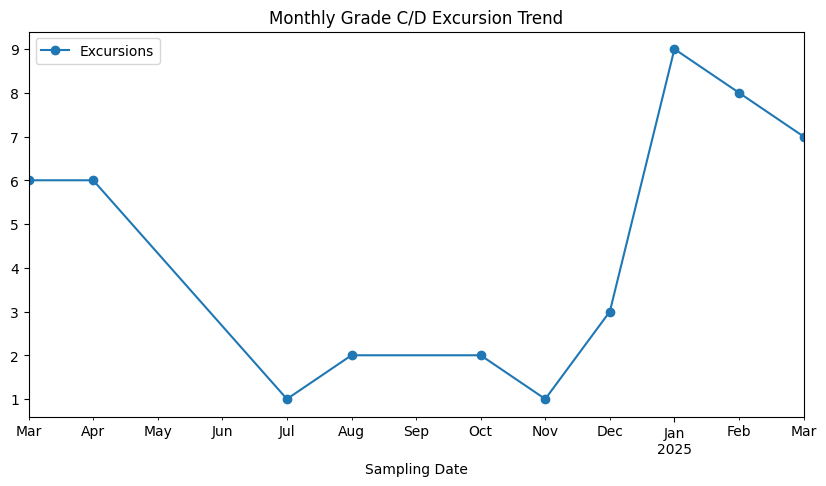

In [9]:
monthly_excursions.plot(
    x="Sampling Date",
    y="Excursions",
    kind="line",
    marker="o",
    figsize=(10,5),
    title="Monthly Grade C/D Excursion Trend"
)

In [11]:
cd = df[df["Grade"].isin(["C", "D"])]

monthly_total = (
    cd.groupby(cd["Sampling Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Total Samples")
)

monthly_exc = (
    cd_excursions.groupby(cd_excursions["Sampling Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Excursions")
)

monthly_rate = monthly_total.merge(
    monthly_exc,
    on="Sampling Date",
    how="left"
)

monthly_rate["Excursions"] = monthly_rate["Excursions"].fillna(0)

monthly_rate["Excursion Rate (%)"] = (
    monthly_rate["Excursions"] /
    monthly_rate["Total Samples"] * 100
)

monthly_rate

,Sampling Date,Total Samples,Excursions,Excursion Rate (%)
0,2024-03,108,6.0,5.555556
1,2024-04,108,6.0,5.555556
2,2024-05,108,0.0,0.000000
3,2024-06,108,0.0,0.000000
4,2024-07,108,1.0,0.925926
5,2024-08,108,2.0,1.851852
6,2024-09,108,0.0,0.000000
7,2024-10,108,2.0,1.851852
8,2024-11,108,1.0,0.925926
9,2024-12,108,3.0,2.777778


In [12]:
recent_excursions = cd_excursions[
    cd_excursions["Sampling Date"].dt.to_period("M").isin(
        ["2025-01", "2025-02", "2025-03"]
    )
]

recent_excursions["Microorganism"].value_counts()

,count
Microorganism,


In [13]:
recent_excursions = cd_excursions[
    cd_excursions["Sampling Date"].dt.to_period("M").isin(
        pd.PeriodIndex(
            ["2025-01", "2025-02", "2025-03"],
            freq="M"
        )
    )
]

recent_excursions["Microorganism"].value_counts()

,count
Microorganism,
Bacillus spp.,12
Penicillium spp.,4
Staphylococcus spp.,4
Aspergillus spp.,3
Micrococcus spp.,1


In [14]:
bacillus_monthly = (
    recent_excursions[
        recent_excursions["Microorganism"] == "Bacillus spp."
    ]
    .groupby(recent_excursions["Sampling Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Bacillus Excursions")
)

bacillus_monthly

,Sampling Date,Bacillus Excursions
0,2025-01,4
1,2025-02,5
2,2025-03,3


In [15]:
schedule_check = (
    cd.groupby(["Grade", "Frequency"])
    .size()
    .reset_index(name="Records")
)

schedule_check

,Grade,Frequency,Records
0,C,Monthly,624
1,D,Monthly,780


In [16]:
schedule_summary = pd.DataFrame({
    "Grade": ["C", "D"],
    "Expected Frequency": ["Fortnightly", "Monthly"],
    "Actual Frequency": ["Monthly", "Monthly"],
    "Schedule Gap": ["Yes", "No"]
})

schedule_summary

,Grade,Expected Frequency,Actual Frequency,Schedule Gap
0,C,Fortnightly,Monthly,Yes
1,D,Monthly,Monthly,No


In [17]:
risk_ranking = (
    cd_excursions
    .groupby("Area Name")
    .agg(
        Total_Excursions=("Risk Level", "size"),
        High_Risk=("Risk Level", lambda x: (x == "High").sum()),
        Medium_Risk=("Risk Level", lambda x: (x == "Medium").sum())
    )
    .sort_values(["High_Risk", "Total_Excursions"], ascending=False)
    .reset_index()
)

risk_ranking

,Area Name,Total_Excursions,High_Risk,Medium_Risk
0,Autoclave Activity Area,11,11,0
1,Media Preparation,7,6,1
2,Inoculation Room,5,5,0
3,DSP 2,2,2,0
4,Washing Room,11,0,11
5,Unloading Room,7,0,7
6,Washing and Unit Preparation,2,0,2


In [18]:
hotspot_summary = (
    cd_excursions
    .groupby(["Area Name", "Probable Source Category"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

hotspot_summary

,Area Name,Probable Source Category,Excursions
15,Washing Room,Spore-former / environmental,6
2,Autoclave Activity Area,Spore-former / environmental,5
1,Autoclave Activity Area,Personnel-associated,5
12,Unloading Room,Personnel-associated,4
9,Media Preparation,Personnel-associated,4
7,Inoculation Room,Spore-former / environmental,3
11,Unloading Room,Mould / environmental,3
14,Washing Room,Personnel-associated,3
8,Media Preparation,Mould / environmental,2
16,Washing and Unit Preparation,Mould / environmental,2


In [19]:
high_risk_area_detail = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    .groupby(
        ["Area Name", "Microorganism", "Probable Source Category"]
    )
    .size()
    .reset_index(name="High Risk Excursions")
    .sort_values("High Risk Excursions", ascending=False)
)

high_risk_area_detail

,Area Name,Microorganism,Probable Source Category,High Risk Excursions
1,Autoclave Activity Area,Bacillus spp.,Spore-former / environmental,5
7,Inoculation Room,Bacillus spp.,Spore-former / environmental,3
3,Autoclave Activity Area,Micrococcus spp.,Personnel-associated,2
12,Media Preparation,Penicillium spp.,Mould / environmental,2
13,Media Preparation,Staphylococcus spp.,Personnel-associated,2
2,Autoclave Activity Area,Corynebacterium spp.,Personnel-associated,2
5,DSP 2,Aspergillus spp.,Mould / environmental,1
4,Autoclave Activity Area,Staphylococcus spp.,Personnel-associated,1
0,Autoclave Activity Area,Aspergillus spp.,Mould / environmental,1
6,DSP 2,Bacillus spp.,Spore-former / environmental,1


In [20]:
micro_risk_summary = (
    cd_excursions
    .groupby(["Microorganism", "Risk Level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

micro_risk_summary

Risk Level,Microorganism,High,Medium
0,Aspergillus spp.,2,3
1,Bacillus spp.,10,6
2,Corynebacterium spp.,3,3
3,Micrococcus spp.,2,1
4,Penicillium spp.,3,4
5,Staphylococcus spp.,4,4


In [21]:
micro_risk_summary = (
    cd_excursions
    .groupby(["Microorganism", "Risk Level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

micro_risk_summary

Risk Level,Microorganism,High,Medium
0,Aspergillus spp.,2,3
1,Bacillus spp.,10,6
2,Corynebacterium spp.,3,3
3,Micrococcus spp.,2,1
4,Penicillium spp.,3,4
5,Staphylococcus spp.,4,4


In [22]:
  risk_ranking = (
    cd_excursions
    .groupby(["Area Name", "Risk Level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

risk_ranking["Total Excursions"] = (
    risk_ranking.get("High", 0) +
    risk_ranking.get("Medium", 0)
)

risk_ranking = risk_ranking.sort_values(
    "Total Excursions",
    ascending=False
)

risk_ranking

Risk Level,Area Name,High,Medium,Total Excursions
0,Autoclave Activity Area,11,0,11
5,Washing Room,0,11,11
3,Media Preparation,6,1,7
4,Unloading Room,0,7,7
2,Inoculation Room,5,0,5
1,DSP 2,2,0,2
6,Washing and Unit Preparation,0,2,2


In [23]:
area_rate = (
    cd.groupby("Area Name")
    .size()
    .reset_index(name="Total Records")
)

area_excursions = (
    cd_excursions.groupby("Area Name")
    .size()
    .reset_index(name="Excursions")
)

area_rate = area_rate.merge(
    area_excursions,
    on="Area Name",
    how="left"
)

area_rate["Excursions"] = area_rate["Excursions"].fillna(0)

area_rate["Excursion Rate (%)"] = (
    area_rate["Excursions"] /
    area_rate["Total Records"] * 100
).round(2)

area_rate.sort_values(
    "Excursion Rate (%)",
    ascending=False
)

,Area Name,Total Records,Excursions,Excursion Rate (%)
0,Autoclave Activity Area,78,11.0,14.10
16,Washing Room,78,11.0,14.10
14,Unloading Room,78,7.0,8.97
13,Media Preparation,78,7.0,8.97
10,Inoculation Room,78,5.0,6.41
7,DSP 2,78,2.0,2.56
17,Washing and Unit Preparation,78,2.0,2.56
1,Buffer Preparation,78,0.0,0.00
4,Corridor 2,78,0.0,0.00
2,Column Storage Room,78,0.0,0.00


In [24]:
area_rate.sort_values(
    "Excursion Rate (%)",
    ascending=False
).head(10)

,Area Name,Total Records,Excursions,Excursion Rate (%)
0,Autoclave Activity Area,78,11.0,14.10
16,Washing Room,78,11.0,14.10
14,Unloading Room,78,7.0,8.97
13,Media Preparation,78,7.0,8.97
10,Inoculation Room,78,5.0,6.41
7,DSP 2,78,2.0,2.56
17,Washing and Unit Preparation,78,2.0,2.56
1,Buffer Preparation,78,0.0,0.00
4,Corridor 2,78,0.0,0.00
2,Column Storage Room,78,0.0,0.00


In [25]:
batch_impact = (
    cd_excursions["Batch Impact Assessment"]
    .value_counts()
    .reset_index()
)

batch_impact.columns = [
    "Batch Impact Assessment",
    "Excursions"
]

batch_impact

,Batch Impact Assessment,Excursions
0,Potential risk to ongoing Teriparatide DS batc...,23
1,No immediate batch-impact signal,22


In [26]:
risk_ranking = (
    cd_excursions
    .groupby(["Area Name", "Risk Level"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

risk_ranking


,Area Name,Risk Level,Excursions
0,Autoclave Activity Area,High,11
6,Washing Room,Medium,11
5,Unloading Room,Medium,7
3,Media Preparation,High,6
2,Inoculation Room,High,5
1,DSP 2,High,2
7,Washing and Unit Preparation,Medium,2
4,Media Preparation,Medium,1


In [27]:
risk_ranking = (
    cd_excursions
    .groupby(["Area Name", "Risk Level"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

risk_ranking

,Area Name,Risk Level,Excursions
0,Autoclave Activity Area,High,11
6,Washing Room,Medium,11
5,Unloading Room,Medium,7
3,Media Preparation,High,6
2,Inoculation Room,High,5
1,DSP 2,High,2
7,Washing and Unit Preparation,Medium,2
4,Media Preparation,Medium,1


In [28]:
area_risk_summary = (
    cd_excursions
    .groupby("Area Name")
    .agg(
        Total_Excursions=("Risk Level", "size"),
        High_Risk=("Risk Level", lambda x: (x == "High").sum()),
        Medium_Risk=("Risk Level", lambda x: (x == "Medium").sum())
    )
    .sort_values(["High_Risk", "Total_Excursions"], ascending=False)
)

area_risk_summary

,Total_Excursions,High_Risk,Medium_Risk
Area Name,,,
Autoclave Activity Area,11,11,0
Media Preparation,7,6,1
Inoculation Room,5,5,0
DSP 2,2,2,0
Washing Room,11,0,11
Unloading Room,7,0,7
Washing and Unit Preparation,2,0,2


In [29]:
mo_summary = (
    cd_excursions["Microorganism"]
    .value_counts()
    .reset_index()
)

mo_summary.columns = ["Microorganism", "Excursions"]

mo_summary["Percentage"] = (
    mo_summary["Excursions"] / mo_summary["Excursions"].sum() * 100
).round(2)

mo_summary

,Microorganism,Excursions,Percentage
0,Bacillus spp.,16,35.56
1,Staphylococcus spp.,8,17.78
2,Penicillium spp.,7,15.56
3,Corynebacterium spp.,6,13.33
4,Aspergillus spp.,5,11.11
5,Micrococcus spp.,3,6.67


In [30]:
mo_area_risk = (
    cd_excursions
    .groupby(["Microorganism", "Area Name", "Risk Level"])
    .size()
    .reset_index(name="Excursions")
    .sort_values("Excursions", ascending=False)
)

mo_area_risk

,Microorganism,Area Name,Risk Level,Excursions
9,Bacillus spp.,Washing Room,Medium,6
5,Bacillus spp.,Autoclave Activity Area,High,5
7,Bacillus spp.,Inoculation Room,High,3
25,Staphylococcus spp.,Washing Room,Medium,2
24,Staphylococcus spp.,Unloading Room,Medium,2
23,Staphylococcus spp.,Media Preparation,High,2
14,Micrococcus spp.,Autoclave Activity Area,High,2
17,Penicillium spp.,Media Preparation,High,2
12,Corynebacterium spp.,Unloading Room,Medium,2
10,Corynebacterium spp.,Autoclave Activity Area,High,2


In [31]:
high_risk_hotspots = mo_area_risk[
    mo_area_risk["Risk Level"] == "High"
].sort_values("Excursions", ascending=False)

high_risk_hotspots

,Microorganism,Area Name,Risk Level,Excursions
5,Bacillus spp.,Autoclave Activity Area,High,5
7,Bacillus spp.,Inoculation Room,High,3
23,Staphylococcus spp.,Media Preparation,High,2
14,Micrococcus spp.,Autoclave Activity Area,High,2
17,Penicillium spp.,Media Preparation,High,2
10,Corynebacterium spp.,Autoclave Activity Area,High,2
8,Bacillus spp.,Media Preparation,High,1
6,Bacillus spp.,DSP 2,High,1
1,Aspergillus spp.,DSP 2,High,1
0,Aspergillus spp.,Autoclave Activity Area,High,1


In [32]:
high_risk_hotspots = mo_area_risk[
    mo_area_risk["Risk Level"] == "High"
].sort_values("Excursions", ascending=False)

high_risk_hotspots

,Microorganism,Area Name,Risk Level,Excursions
5,Bacillus spp.,Autoclave Activity Area,High,5
7,Bacillus spp.,Inoculation Room,High,3
23,Staphylococcus spp.,Media Preparation,High,2
14,Micrococcus spp.,Autoclave Activity Area,High,2
17,Penicillium spp.,Media Preparation,High,2
10,Corynebacterium spp.,Autoclave Activity Area,High,2
8,Bacillus spp.,Media Preparation,High,1
6,Bacillus spp.,DSP 2,High,1
1,Aspergillus spp.,DSP 2,High,1
0,Aspergillus spp.,Autoclave Activity Area,High,1


In [33]:
risk_method = pd.crosstab(
    cd_excursions["Monitoring Method"],
    cd_excursions["Risk Level"]
)

risk_method

Risk Level,High,Medium
Monitoring Method,,
Active Air Sampling,3,4
Settle Plate,8,10
Surface Monitoring,13,7


In [34]:
final_risk_summary = pd.DataFrame({
    "Metric": [
        "Total C/D Excursions",
        "High Risk Excursions",
        "Medium Risk Excursions",
        "High Risk %"
    ],
    "Value": [
        len(cd_excursions),
        (cd_excursions["Risk Level"] == "High").sum(),
        (cd_excursions["Risk Level"] == "Medium").sum(),
        round(
            (cd_excursions["Risk Level"] == "High").sum()
            / len(cd_excursions) * 100,
            2
        )
    ]
})

final_risk_summary

,Metric,Value
0,Total C/D Excursions,45.00
1,High Risk Excursions,24.00
2,Medium Risk Excursions,21.00
3,High Risk %,53.33


In [35]:
df["Excursion_Flag"] = (
    df["Result Status"] != "Within Limit"
).astype(int)

df["Excursion_Flag"].value_counts()

,count
Excursion_Flag,
0,2564
1,184


In [36]:
df.select_dtypes(include="object").columns

Index(['Sample ID', 'Area ID', 'Area Name', 'Grade', 'Frequency',
       'Monitoring Method', 'Condition', 'Product / Process', 'Batch ID',
       'Ongoing Batch', 'Result Status', 'Microorganism',
       'Probable Source Category', 'Recurring Organism', 'DET Required',
       'DET Status', 'Risk Level', 'Batch Impact Assessment'],
      dtype='object')

In [37]:
df[["CFU Result", "Grade", "Monitoring Method", "Condition", "Ongoing Batch", "Excursion_Flag"]].head(

)

,CFU Result,Grade,Monitoring Method,Condition,Ongoing Batch,Excursion_Flag
0,0,A,Active Air Sampling,At Rest,No,0
1,0,A,Active Air Sampling,During Operation,No,0
2,0,A,Settle Plate,At Rest,No,0
3,0,A,Settle Plate,During Operation,No,0
4,0,A,Surface Monitoring,At Rest,No,0


In [38]:
df[["CFU Result", "Grade", "Monitoring Method", "Condition", "Ongoing Batch", "Excursion_Flag"]].dtypes

,0
CFU Result,int64
Grade,object
Monitoring Method,object
Condition,object
Ongoing Batch,object
Excursion_Flag,int64


In [39]:
X = df[["CFU Result", "Grade", "Monitoring Method", "Condition", "Ongoing Batch"]]

y = df["Excursion_Flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2748, 5)
y shape: (2748,)


In [41]:
X.select_dtypes(include="object").columns

Index(['Grade', 'Monitoring Method', 'Condition', 'Ongoing Batch'], dtype='object')

In [42]:
for col in X.select_dtypes(include="object").columns:
    print(col, ":", X[col].unique())

Grade : ['A' 'C' 'D']
Monitoring Method : ['Active Air Sampling' 'Settle Plate' 'Surface Monitoring']
Condition : ['At Rest' 'During Operation']
Ongoing Batch : ['No' 'Yes']


In [43]:
X_encoded = pd.get_dummies(
    X,
    columns=["Grade", "Monitoring Method", "Condition", "Ongoing Batch"],
    drop_first=True
)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

X_encoded.head()

Before encoding: (2748, 5)
After encoding: (2748, 7)


,CFU Result,Grade_C,Grade_D,Monitoring Method_Settle Plate,Monitoring Method_Surface Monitoring,Condition_During Operation,Ongoing Batch_Yes
0,0,False,False,False,False,False,False
1,0,False,False,False,False,True,False
2,0,False,False,True,False,False,False
3,0,False,False,True,False,True,False
4,0,False,False,False,True,False,False


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2198, 7)
X_test: (550, 7)
y_train: (2198,)
y_test: (550,)


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

Confusion Matrix:
[[513   0]
 [ 37   0]]
Accuracy: 0.9327272727272727
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [47]:
print(y_train.value_counts())
print(y_test.value_counts())

Excursion_Flag
0    2051
1     147
Name: count, dtype: int64
Excursion_Flag
0    513
1     37
Name: count, dtype: int64


In [48]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(y_pred_balanced[:20])

[1 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0]


In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_balanced, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_balanced, zero_division=0))

Confusion Matrix:
[[315 198]
 [  3  34]]
Accuracy: 0.6345454545454545
Precision: 0.14655172413793102
Recall: 0.918918918918919
F1 Score: 0.2527881040892193


In [50]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(y_pred_dt[:20])


[0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0]


In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_dt, zero_division=0))

Confusion Matrix:
[[491  22]
 [  2  35]]
Accuracy: 0.9563636363636364
Precision: 0.6140350877192983
Recall: 0.9459459459459459
F1 Score: 0.7446808510638298


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0]


In [53]:
     from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))

Confusion Matrix:
[[500  13]
 [  1  36]]
Accuracy: 0.9745454545454545
Precision: 0.7346938775510204
Recall: 0.972972972972973
F1 Score: 0.8372093023255814


In [54]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932727,0.000000,0.000000,0.000000
1,Decision Tree,0.956364,0.614035,0.945946,0.744681
2,Random Forest,0.974545,0.734694,0.972973,0.837209


In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
0,CFU Result,0.721524
2,Grade_D,0.123558
1,Grade_C,0.066911
5,Condition_During Operation,0.044012
6,Ongoing Batch_Yes,0.025538
4,Monitoring Method_Surface Monitoring,0.011755
3,Monitoring Method_Settle Plate,0.006702


In [56]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
0,CFU Result,0.721524
2,Grade_D,0.123558
1,Grade_C,0.066911
5,Condition_During Operation,0.044012
6,Ongoing Batch_Yes,0.025538
4,Monitoring Method_Surface Monitoring,0.011755
3,Monitoring Method_Settle Plate,0.006702


In [57]:
X_clean = df[
    ["Grade", "Monitoring Method", "Condition", "Ongoing Batch"]
]

X_clean = pd.get_dummies(
    X_clean,
    drop_first=True
)

y = df["Excursion_Flag"]

print("X_clean shape:", X_clean.shape)
print("y shape:", y.shape)

X_clean shape: (2748, 6)
y shape: (2748,)


In [58]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train_clean.shape)
print("X_test:", X_test_clean.shape)
print("y_train:", y_train_clean.shape)
print("y_test:", y_test_clean.shape)

X_train: (2198, 6)
X_test: (550, 6)
y_train: (2198,)
y_test: (550,)


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf_clean.fit(X_train_clean, y_train_clean)

y_pred_rf_clean = rf_clean.predict(X_test_clean)

print(y_pred_rf_clean[:20])

[0 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 1]


In [61]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm_rf_clean = confusion_matrix(y_test_clean, y_pred_rf_clean)

print("Confusion Matrix:")
print(cm_rf_clean)

print("Accuracy:", accuracy_score(y_test_clean, y_pred_rf_clean))
print("Precision:", precision_score(y_test_clean, y_pred_rf_clean, zero_division=0))
print("Recall:", recall_score(y_test_clean, y_pred_rf_clean, zero_division=0))
print("F1 Score:", f1_score(y_test_clean, y_pred_rf_clean, zero_division=0))

Confusion Matrix:
[[226 287]
 [  1  36]]
Accuracy: 0.4763636363636364
Precision: 0.11145510835913312
Recall: 0.972972972972973
F1 Score: 0.2


In [63]:
feature_importance_clean = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf_clean.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_clean

,Feature,Importance
1,Grade_D,0.412437
0,Grade_C,0.212373
4,Condition_During Operation,0.188883
5,Ongoing Batch_Yes,0.086160
3,Monitoring Method_Surface Monitoring,0.058274
2,Monitoring Method_Settle Plate,0.041873


In [64]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_clean,
    X_clean,
    y,
    cv=5,
    scoring="f1"
)

print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.1952862  0.17901235 0.22545455 0.16402116 0.17610063]
Mean CV F1: 0.18797497587434692


In [65]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_tuned = RandomizedSearchCV(
    rf_clean,
    param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_clean, y)

print("Best Parameters:", rf_tuned.best_params_)
print("Best CV F1:", rf_tuned.best_score_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Best CV F1: 0.18789813236368202


In [66]:
rf_tuned = RandomizedSearchCV(
    rf_clean,
    param_grid,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_clean, y_train_clean)

print("Best Parameters:", rf_tuned.best_params_)
print("Best CV F1:", rf_tuned.best_score_)

Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Best CV F1: 0.18873511462120832


In [67]:
y_pred_tuned = rf_tuned.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test_clean, y_pred_tuned))
print("Precision:", precision_score(y_test_clean, y_pred_tuned, zero_division=0))
print("Recall:", recall_score(y_test_clean, y_pred_tuned, zero_division=0))
print("F1 Score:", f1_score(y_test_clean, y_pred_tuned, zero_division=0))

Accuracy: 0.4763636363636364
Precision: 0.11145510835913312
Recall: 0.972972972972973
F1 Score: 0.2


In [68]:
from sklearn.metrics import roc_auc_score

y_prob_tuned = rf_tuned.predict_proba(X_test_clean)[:, 1]

auc_tuned = roc_auc_score(y_test_clean, y_prob_tuned)

print("ROC-AUC:", auc_tuned)

ROC-AUC: 0.711738053843317


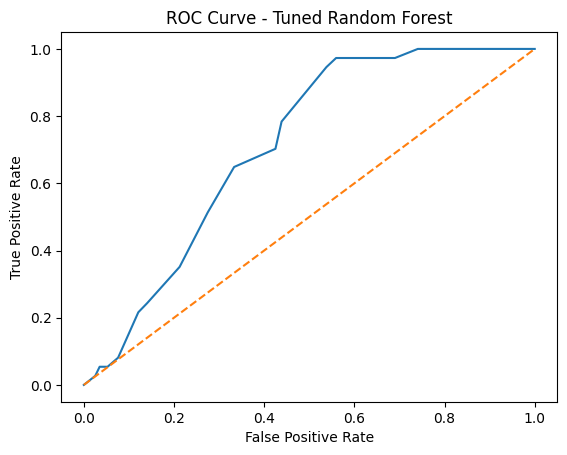

In [69]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_clean, y_prob_tuned)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.show()

In [70]:
final_model_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test_clean, y_pred_tuned),
        precision_score(y_test_clean, y_pred_tuned, zero_division=0),
        recall_score(y_test_clean, y_pred_tuned, zero_division=0),
        f1_score(y_test_clean, y_pred_tuned, zero_division=0),
        auc_tuned
    ]
})

final_model_summary

,Metric,Value
0,Accuracy,0.476364
1,Precision,0.111455
2,Recall,0.972973
3,F1 Score,0.200000
4,ROC-AUC,0.711738


In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds:
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

    print(
        "Threshold:", threshold,
        "| Precision:", round(precision_score(y_test_clean, y_pred_threshold, zero_division=0), 3),
        "| Recall:", round(recall_score(y_test_clean, y_pred_threshold, zero_division=0), 3),
        "| F1:", round(f1_score(y_test_clean, y_pred_threshold, zero_division=0), 3)
    )

Threshold: 0.3 | Precision: 0.094 | Recall: 0.973 | F1: 0.171
Threshold: 0.4 | Precision: 0.107 | Recall: 0.973 | F1: 0.194
Threshold: 0.5 | Precision: 0.111 | Recall: 0.973 | F1: 0.2
Threshold: 0.6 | Precision: 0.107 | Recall: 0.351 | F1: 0.164
Threshold: 0.7 | Precision: 0.1 | Recall: 0.054 | F1: 0.07
Threshold: 0.8 | Precision: 0.0 | Recall: 0.0 | F1: 0.0


In [72]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = (y_prob_tuned >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test_clean, y_pred_final, zero_division=0))

Confusion Matrix:
[[226 287]
 [  1  36]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.44      0.61       513
           1       0.11      0.97      0.20        37

    accuracy                           0.48       550
   macro avg       0.55      0.71      0.41       550
weighted avg       0.94      0.48      0.58       550



In [73]:
high_risk_areas = (
    cd_excursions[cd_excursions["Risk Level"] == "High"]
    ["Area Name"]
    .value_counts()
)

high_risk_areas

,count
Area Name,
Autoclave Activity Area,11
Media Preparation,6
Inoculation Room,5
DSP 2,2


In [74]:
cd_excursions["Risk Level"].value_counts()

,count
Risk Level,
High,24
Medium,21


In [75]:
pd.crosstab(
    cd_excursions["Grade"],
    cd_excursions["Risk Level"]
)

Risk Level,High,Medium
Grade,,
C,24,10
D,0,11


In [76]:
cd_excursions["Sampling Date"] = pd.to_datetime(cd_excursions["Sampling Date"])

cd_excursions["Sampling Date"].dt.month.value_counts().sort_index()

/tmp/ipykernel_2051/1061870075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd_excursions["Sampling Date"] = pd.to_datetime(cd_excursions["Sampling Date"])


,count
Sampling Date,
1,9
2,8
3,13
4,6
7,1
8,2
10,2
11,1
12,3


In [77]:
print("Final Model: Tuned Random Forest")
print("ROC-AUC:", round(auc_tuned, 3))
print("Recall:", round(recall_score(y_test_clean, y_pred_tuned), 3))
print("F1 Score:", round(f1_score(y_test_clean, y_pred_tuned), 3))

Final Model: Tuned Random Forest
ROC-AUC: 0.712
Recall: 0.973
F1 Score: 0.2


In [79]:
print("PROJECT KEY INSIGHTS")
print("--------------------")

print("1. High-risk areas:", high_risk_areas.to_dict())
print("2. Risk distribution:", cd_excursions["Risk Level"].value_counts().to_dict())
print("3. Final model ROC-AUC:", round(auc_tuned, 3))
print("4. Final model Recall:", round(recall_score(y_test_clean, y_pred_tuned), 3))

PROJECT KEY INSIGHTS
--------------------
1. High-risk areas: {'Autoclave Activity Area': 11, 'Media Preparation': 6, 'Inoculation Room': 5, 'DSP 2': 2}
2. Risk distribution: {'High': 24, 'Medium': 21}
3. Final model ROC-AUC: 0.712
4. Final model Recall: 0.973


In [81]:
print("PROJECT RECOMMENDATIONS")
print("----------------------")
print("1. Focus on high-risk areas.")
print("2. Prioritize During Operation monitoring.")
print("3. Investigate recurring microorganisms and probable sources.")
print("4. Use ML as an early-warning decision-support tool.")

PROJECT RECOMMENDATIONS
----------------------
1. Focus on high-risk areas.
2. Prioritize During Operation monitoring.
3. Investigate recurring microorganisms and probable sources.
4. Use ML as an early-warning decision-support tool.


## Final Conclusion

The Environmental Monitoring analysis identified key high-risk areas and microbial contamination patterns across Grade C and Grade D areas.

The tuned Random Forest model achieved a ROC-AUC of 0.712 and high recall of 0.973, indicating useful potential for identifying contamination-risk events.

The analysis can support:
- High-risk area prioritization
- During Operation monitoring focus
- Microorganism/source investigation
- Early-warning risk assessment

The ML model should be used as a decision-support tool along with established Environmental Monitoring, investigation, QA and CAPA procedures.

## Pharmaceutical Environmental Monitoring & Contamination Risk Analytics
#### Project Overview

This project analyzes pharmaceutical Environmental Monitoring (EM) data to identify microbial contamination patterns, high-risk areas, recurring microorganisms, and contamination-risk events.

A Machine Learning model is used as a decision-support tool for early risk identification.

### Project Objectives

- Identify microbial contamination patterns.
- Identify high-risk areas and recurring microorganisms.
- Analyze contamination risk during operations.
- Develop an ML-based early warning risk assessment.
- Support Environmental Monitoring, investigation and CAPA decisions.

### Project Workflow

EM Data → Data Cleaning → EDA → Microorganism Analysis → Risk Analysis → Feature Engineering → ML Model → Model Evaluation → Key Insights & Recommendations

### Dataset Summary

- Dataset: Pharmaceutical Environmental Monitoring (EM)
- Scope: Grade C and Grade D areas
- Monitoring: Settle Plate, Active Air Sampling, Surface Monitoring
- Conditions: At Rest and During Operation
- Target: Microbial contamination risk / excursion prediction

### Key Findings

- Grade C/D excursions were mainly observed During Operation.
- Bacillus spp. was the most frequent microorganism among excursions.
- High-risk areas included Autoclave Activity Area, Media Preparation, Inoculation Room and DSP 2.
- Most excursions were classified as High or Medium risk.
- The ML model showed high recall for identifying risk events.

## Risk & Control Strategy

The identified contamination patterns can be used to support a risk-based control strategy.

- Prioritize high-risk areas for focused Environmental Monitoring review.
- Strengthen During Operation monitoring and investigation of excursions.
- Investigate recurring microorganisms and their probable source categories.
- Review personnel practices, cleaning and disinfection, utilities, HVAC and equipment-related factors during investigations.
- Use contamination trends and ML predictions as decision-support inputs for investigation and CAPA.
- Specific corrective actions should follow validated site procedures, QA requirements and applicable regulatory controls.

## Project Limitations

- The dataset is limited to available Environmental Monitoring parameters.
- RH, temperature, HVAC and personnel data were not directly available for modelling.
- ML predictions should be treated as decision-support, not as a replacement for QA investigation or CAPA procedures.

## Project Scope & Dataset Context

- Focus: Grade C and Grade D Environmental Monitoring areas.
- Monitoring methods: Settle Plate, Active Air Sampling and Surface Monitoring.
- Conditions: At Rest and During Operation.
- Analysis focus: contamination patterns, microorganisms, risk areas and excursions.
- ML focus: early-warning contamination risk prediction.